In [ ]:
import sys, os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
DRIVE_MOUNT = '/content/drive'

if IN_COLAB:
    from google.colab import drive
    if not Path(DRIVE_MOUNT + '/MyDrive').exists():
        drive.mount(DRIVE_MOUNT)
    print(f'Drive mounted: {Path(DRIVE_MOUNT + "/MyDrive").exists()}')
else:
    print('Bukan di Colab - skip mount drive (jalan lokal).')

Mounted at /content/drive
Drive mounted: True


In [ ]:
# ============================================================
# CELL 0 — Imports + Config
# ============================================================

import os
import gc
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────
# Root direktori feature CSVs
CSV_ROOT_BASELINE = Path('/content/drive/MyDrive/FP_Admin_KCV/fp/raw_features/fe_vig_dinov2')
CSV_ROOT_MEDICAL  = Path('/content/drive/MyDrive/FP_Admin_KCV/fp/raw_features/kaggle_dual_scenario')

# Checkpoint output
CKPT_DIR = Path('/content/drive/MyDrive/FP_Admin_KCV/fp/checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Mapping: (fe_tag, split_tag) → CSV path
CSV_MAP = {
    ('dinov2',      'balanced'):   CSV_ROOT_BASELINE / 'dinov2_balanced_vektor.csv',
    ('dinov2',      'imbalanced'): CSV_ROOT_BASELINE / 'dinov2_imbalanced_vektor.csv',
    ('swin',        'balanced'):   CSV_ROOT_BASELINE / 'swin_balanced_vektor.csv',
    ('swin',        'imbalanced'): CSV_ROOT_BASELINE / 'swin_imbalanced_vektor.csv',
    ('maxvit',      'balanced'):   CSV_ROOT_BASELINE / 'features_maxvit_balanced.csv',
    ('maxvit',      'imbalanced'): CSV_ROOT_BASELINE / 'features_maxvit_imbalanced.csv',
    ('convnextv2',  'balanced'):   CSV_ROOT_BASELINE / 'features_convnextv2_balanced.csv',
    ('convnextv2',  'imbalanced'): CSV_ROOT_BASELINE / 'features_convnextv2_imbalanced.csv',
    ('medical',     'balanced'):   CSV_ROOT_MEDICAL  / 'medical_balanced_vektor_timestep_10.csv',
    ('medical',     'imbalanced'): CSV_ROOT_MEDICAL  / 'medical_imbalanced_vektor_timestep_10.csv',
}

# Semua FE yang dianalisis
ALL_FE = ['dinov2', 'swin', 'maxvit', 'convnextv2', 'medical']

# ── Hyperparameters ───────────────────────────────────────────
EPOCHS      = 50
BATCH_SIZE  = 64
LR          = 1e-3
WEIGHT_DECAY= 1e-4
MLP_HIDDEN  = 512
DROPOUT     = 0.3
NUM_CLASSES = 6
VAL_RATIO   = 0.15   # 15% val
TEST_RATIO  = 0.15   # 15% test (dari keseluruhan)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


Device: cuda


In [ ]:
# ============================================================
# CELL 1 — Dataset & Data Utilities
# ============================================================

class FeatureDataset(Dataset):
    """Dataset dari pre-extracted feature vectors (CSV rows)."""
    def __init__(self, features: np.ndarray, labels: np.ndarray):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def load_csv_splits(csv_path: Path):
    """Baca CSV dan split stratified 70/15/15 → (train, val, test) dataset + class_weights tensor."""
    df = pd.read_csv(csv_path)

    # Kolom fitur: semua kolom numerik selain 'label'
    # (handles berbagai nama kolom filename: 'image_name', 'filename', 'image', dst.)
    non_feat = {'label'}
    feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in non_feat]
    X = df[feat_cols].values.astype(np.float32)

    # Encode string labels → integer indices jika belum numerik
    raw_labels = df['label'].values
    if not np.issubdtype(raw_labels.dtype, np.integer):
        classes = sorted(set(raw_labels))
        label_map = {cls: i for i, cls in enumerate(classes)}
        print(f'  Label encoding: {label_map}')
        raw_labels = np.array([label_map[v] for v in raw_labels])
    y = raw_labels.astype(np.int64)

    # Split: 70 train | 15 val | 15 test (stratified)
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=(VAL_RATIO + TEST_RATIO), random_state=SEED, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp
    )

    # Class weights dari training split saja
    counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
    counts = np.where(counts == 0, 1, counts)   # hindari div-by-zero
    weights = len(y_train) / (NUM_CLASSES * counts)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    train_ds = FeatureDataset(X_train, y_train)
    val_ds   = FeatureDataset(X_val,   y_val)
    test_ds  = FeatureDataset(X_test,  y_test)

    print(f'  Split → train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}')
    print(f'  feat_dim={X.shape[1]}  |  class_weights={weights.round(3)}')

    return train_ds, val_ds, test_ds, class_weights, int(X.shape[1])

#

In [ ]:
# ============================================================
# CELL 2 — MLP Classifier
# ============================================================

class MLPClassifier(nn.Module):
    """
    LayerNorm → Linear(feat_dim, MLP_HIDDEN) → GELU → Dropout → Linear(MLP_HIDDEN, num_classes)
    Mirip head dari XRayClassifier di notebook, tapi tanpa timm backbone
    karena fitur sudah di-ekstrak sebelumnya.
    """
    def __init__(self, feat_dim: int, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, MLP_HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(MLP_HIDDEN, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 3 — Feature Space Augmentation (FSA) — Revised
# ============================================================
# Tiga metode:
#   1. Feature Space SMOTE  — oversample kelas minoritas di ruang fitur
#   2. Gaussian Noise Injection — perturbasi ringan seluruh batch
#   3. Mixup — interpolasi linear antar sampel + soft label

import random

# ── 1. Feature Space SMOTE ───────────────────────────────────

def feature_smote(x: torch.Tensor, y: torch.Tensor,
                  num_classes: int = NUM_CLASSES,
                  k: int = 5) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Synthetic oversampling di ruang fitur (analog SMOTE).
    Untuk setiap kelas minoritas, buat sampel sintetis dengan
    interpolasi acak antara sampel asli dan salah satu k-NN-nya
    (approx: k-NN dari kelas yang sama dalam batch ini).

    Hanya membuat sampel untuk kelas yang jumlahnya < median count.
    Mengembalikan (x_syn, y_syn) — harus di-concat dengan (x, y) asli.
    """
    x_cpu = x.detach().cpu()
    y_cpu = y.detach().cpu().numpy()

    counts = np.bincount(y_cpu, minlength=num_classes)
    median_count = int(np.median(counts[counts > 0]))

    syn_x_list, syn_y_list = [], []

    for cls in range(num_classes):
        idx = np.where(y_cpu == cls)[0]
        n = len(idx)
        if n == 0 or n >= median_count:
            continue                    # skip kelas mayoritas / kosong

        x_cls = x_cpu[idx]             # (n, feat_dim)
        n_syn = median_count - n       # jumlah sampel sintetis yang dibutuhkan

        # Pilih pasangan secara acak (tanpa k-NN eksak agar tetap efisien)
        i1 = torch.randint(0, n, (n_syn,))
        i2 = torch.randint(0, n, (n_syn,))
        lam = torch.rand(n_syn, 1)     # interpolasi acak ∈ [0,1]

        x_syn = lam * x_cls[i1] + (1 - lam) * x_cls[i2]
        y_syn = torch.full((n_syn,), cls, dtype=torch.long)

        syn_x_list.append(x_syn)
        syn_y_list.append(y_syn)

    if not syn_x_list:
        return x, y                    # tidak ada kelas minoritas → kembalikan asli

    x_syn_all = torch.cat(syn_x_list, dim=0).to(x.device)
    y_syn_all = torch.cat(syn_y_list, dim=0).to(y.device)

    x_out = torch.cat([x, x_syn_all], dim=0)
    y_out = torch.cat([y, y_syn_all], dim=0)

    return x_out, y_out


# ── 2. Gaussian Noise Injection ──────────────────────────────

def gaussian_noise(x: torch.Tensor, sigma: float = 0.01) -> torch.Tensor:
    """Tambahkan noise Gaussian iid N(0, sigma²) ke setiap fitur."""
    return x + torch.randn_like(x) * sigma


# ── 3. Mixup ─────────────────────────────────────────────────

def mixup(x: torch.Tensor, y: torch.Tensor,
          num_classes: int = NUM_CLASSES,
          alpha: float = 0.2) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Mixup di ruang fitur.
    λ ~ Beta(alpha, alpha); interpolasi pasangan (x_i, x_j).
    Mengembalikan (x_mix, y_soft) — y_soft adalah soft label one-hot.
    """
    B = x.size(0)
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(B, device=x.device)

    x_mix = lam * x + (1 - lam) * x[idx]

    # One-hot → soft label setelah mixup
    y_onehot = torch.zeros(B, num_classes, device=x.device)
    y_onehot.scatter_(1, y.unsqueeze(1), 1.0)
    y_soft = lam * y_onehot + (1 - lam) * y_onehot[idx]

    return x_mix, y_soft


# ── Pipeline utama ────────────────────────────────────────────

def apply_fsa(x: torch.Tensor, y: torch.Tensor,
              num_classes: int = NUM_CLASSES) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Tiga-tahap FSA yang dipanggil di train_epoch saat use_aug=True.

    Urutan:
      1. FS-SMOTE   → perluas batch dengan sampel sintetis kelas minoritas
      2. Gaussian Noise → perturbasi seluruh batch (asli + sintetis)
      3. Mixup       → interpolasi antar sampel + soft label

    Mengembalikan (x_aug, y_soft) untuk soft_cross_entropy.
    """
    # Tahap 1: FS-SMOTE (hanya relevan untuk scenario imbalanced,
    #          pada balanced tidak ada efek karena count ≈ median)
    x, y = feature_smote(x, y, num_classes=num_classes)

    # Tahap 2: Gaussian Noise
    x = gaussian_noise(x, sigma=0.01)

    # Tahap 3: Mixup → output sudah berupa soft label
    x_aug, y_soft = mixup(x, y, num_classes=num_classes, alpha=0.2)

    return x_aug, y_soft


def soft_cross_entropy(logits: torch.Tensor,
                       soft_targets: torch.Tensor) -> torch.Tensor:
    """CrossEntropy dengan soft (mixup) targets — tidak berubah."""
    log_probs = torch.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

In [ ]:
# def apply_fsa(x: torch.Tensor, y: torch.Tensor, num_classes: int = NUM_CLASSES):
#     """
#     Feature Space Augmentation — diterapkan hanya saat training.
#     Returns augmented (x, y_soft).

#     Techniques:
#       1. Gaussian noise injection
#       2. Feature dropout mask (10% dims → 0)
#       3. Mixup in feature space
#     """
#     B = x.size(0)

#     # 1. Gaussian noise
#     x = x + torch.randn_like(x) * 0.01

#     # 2. Feature dropout mask
#     mask = (torch.rand_like(x) > 0.10).float()
#     x = x * mask

#     # 3. Mixup
#     alpha = 0.2
#     lam   = np.random.beta(alpha, alpha)
#     idx   = torch.randperm(B, device=x.device)
#     x     = lam * x + (1 - lam) * x[idx]

#     # One-hot encode labels → soft labels setelah mixup
#     y_onehot = torch.zeros(B, num_classes, device=x.device)
#     y_onehot.scatter_(1, y.unsqueeze(1), 1.0)
#     y_mix_onehot = lam * y_onehot + (1 - lam) * y_onehot[idx]

#     return x, y_mix_onehot   # y_mix_onehot untuk soft CrossEntropy


# def soft_cross_entropy(logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
#     """CrossEntropy dengan soft (mixup) targets."""
#     log_probs = torch.log_softmax(logits, dim=1)
#     return -(soft_targets * log_probs).sum(dim=1).mean()


In [ ]:
# ============================================================
# CELL 4 — Training & Evaluation Loop
# ============================================================

def train_epoch(model, loader, optimizer, criterion, use_aug: bool = False):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()

        if use_aug:
            x_aug, y_soft = apply_fsa(x, y)
            logits = model(x_aug)
            loss   = soft_cross_entropy(logits, y_soft)
        else:
            logits = model(x)
            loss   = criterion(logits, y)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader):
    """Returns (acc, f1_macro, auc_ovr, all_preds, all_labels, all_probs)."""
    model.eval()
    all_logits, all_labels = [], []

    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_labels.append(y)

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    probs  = torch.softmax(logits, dim=1).numpy()
    preds  = logits.argmax(dim=1).numpy()

    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
    except ValueError:
        auc = float('nan')

    return acc, f1, auc, preds, labels, probs

In [ ]:
# ============================================================
# CELL 5 — run_experiment: wrapper untuk 1 FE × 1 scenario
# ============================================================

def run_experiment(fe_tag: str, split_tag: str, scenario_num: int,
                   use_aug: bool = False) -> dict:
    """
    Load CSV → split → train MLP → evaluate test set.
    Simpan best checkpoint berdasarkan val F1-macro.

    Returns dict dengan kolom untuk summary table.
    """
    csv_path = CSV_MAP.get((fe_tag, split_tag))
    if csv_path is None or not csv_path.exists():
        print(f'  [SKIP] CSV tidak ditemukan: {csv_path}')
        return {}

    aug_label = '+aug' if use_aug else ''
    exp_tag   = f'sc{scenario_num}_{fe_tag}_{split_tag}{aug_label}'
    ckpt_path = CKPT_DIR / f'{exp_tag}_best.pt'

    print(f'\n{"=" * 55}')
    print(f'  Scenario {scenario_num} | FE={fe_tag}  |  split={split_tag}  |  aug={use_aug}')
    print(f'{"=" * 55}')

    train_ds, val_ds, test_ds, class_weights, feat_dim = load_csv_splits(csv_path)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model     = MLPClassifier(feat_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_f1 = -1.0
    best_epoch  = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, use_aug)
        scheduler.step()
        val_acc, val_f1, val_auc, _, _, _ = eval_epoch(model, val_loader)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            torch.save(model.state_dict(), ckpt_path)

        if epoch % 10 == 0 or epoch == EPOCHS:
            print(f'  Epoch {epoch:3d}/{EPOCHS}  loss={train_loss:.4f}  '
                  f'val_acc={val_acc:.4f}  val_f1={val_f1:.4f}  val_auc={val_auc:.4f}')

    # Load best checkpoint → evaluate on test
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    test_acc, test_f1, test_auc, _, _, _ = eval_epoch(model, test_loader)

    print(f'\n  >> Best epoch: {best_epoch}  |  '
          f'Test Acc={test_acc:.4f}  F1={test_f1:.4f}  AUC={test_auc:.4f}')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        'Scenario':         scenario_num,
        'Model':            fe_tag,
        'Dataset':          f'{split_tag}{aug_label}',
        'Best Epoch':       best_epoch,
        'Test Acc':         round(test_acc, 4),
        'Test F1 (macro)':  round(test_f1,  4),
        'Test AUC (OvR)':   round(test_auc, 4),
    }


In [ ]:

# ============================================================
# CELL 6 — Scenario 1: Balanced, semua FE, tanpa augmentasi
# ============================================================
# CSV balanced untuk: dinov2, swin, maxvit, convnextv2, medical
# Tidak ada augmentasi.

results = []

print('\n\n########## SCENARIO 1 — Balanced, No Augmentation ##########')
for fe in ALL_FE:
    r = run_experiment(fe_tag=fe, split_tag='balanced', scenario_num=1, use_aug=False)
    if r:
        results.append(r)



########## SCENARIO 1 — Balanced, No Augmentation ##########

  Scenario 1 | FE=dinov2  |  split=balanced  |  aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]
  Epoch  10/50  loss=1.6184  val_acc=0.3493  val_f1=0.3090  val_auc=0.6991
  Epoch  20/50  loss=1.4996  val_acc=0.2987  val_f1=0.2630  val_auc=0.7084
  Epoch  30/50  loss=1.4085  val_acc=0.3493  val_f1=0.3277  val_auc=0.7146
  Epoch  40/50  loss=1.3522  val_acc=0.3787  val_f1=0.3741  val_auc=0.7148
  Epoch  50/50  loss=1.3387  val_acc=0.3547  val_f1=0.3551  val_auc=0.7137

  >> Best epoch: 40  |  Test Acc=0.3333  F1=0.3261  AUC=0.7100

  Scenario 1 | FE=swin  |  split=balanced  |  aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]
  Epoch  10/50  loss=1.4689  val_acc=0.3093  val_f1=0.3053  val_auc=0.7031
  Epoch  20/50  loss=1.2157  val_acc=0.3653  val_f1=0.3611  val_auc=0.7097
  Epo

In [ ]:
 #============================================================
# CELL 7 — Scenario 2: Balanced + Feature Space Augmentation
# ============================================================
# Semua FE pada dataset balanced, dengan FSA (Gaussian noise +
# feature dropout mask + Mixup) diterapkan saat training.

print('\n\n########## SCENARIO 2 — Balanced + Feature Space Augmentation ##########')
for fe in ALL_FE:
    r = run_experiment(fe_tag=fe, split_tag='balanced', scenario_num=2, use_aug=True)
    if r:
        results.append(r)



########## SCENARIO 2 — Balanced + Feature Space Augmentation ##########

  Scenario 2 | FE=dinov2  |  split=balanced  |  aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]
  Epoch  10/50  loss=1.6167  val_acc=0.2907  val_f1=0.2478  val_auc=0.6977
  Epoch  20/50  loss=1.5174  val_acc=0.3493  val_f1=0.3456  val_auc=0.7107
  Epoch  30/50  loss=1.4354  val_acc=0.3333  val_f1=0.3337  val_auc=0.7133
  Epoch  40/50  loss=1.3952  val_acc=0.3387  val_f1=0.3373  val_auc=0.7144
  Epoch  50/50  loss=1.3693  val_acc=0.3653  val_f1=0.3654  val_auc=0.7139

  >> Best epoch: 31  |  Test Acc=0.3227  F1=0.3191  AUC=0.7097

  Scenario 2 | FE=swin  |  split=balanced  |  aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]
  Epoch  10/50  loss=1.4795  val_acc=0.3280  val_f1=0.3038  val_auc=0.7062
  Epoch  20/50  loss=1.3054  val_acc=0.3387  val_f1=0.3268  val_auc=0.

In [ ]:
# ============================================================
# CELL 8 — Scenario 3: Imbalanced, semua FE, tanpa augmentasi
# ============================================================
# Semua FE pada dataset imbalanced.
# Class weights menangani skew No Finding:Lainnya ≈ 1500:200.

print('\n\n########## SCENARIO 3 — Imbalanced, No Augmentation ##########')
for fe in ALL_FE:
    r = run_experiment(fe_tag=fe, split_tag='imbalanced', scenario_num=3, use_aug=False)
    if r:
        results.append(r)



########## SCENARIO 3 — Imbalanced, No Augmentation ##########

  Scenario 3 | FE=dinov2  |  split=imbalanced  |  aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]
  Epoch  10/50  loss=1.6400  val_acc=0.5013  val_f1=0.2672  val_auc=0.6888
  Epoch  20/50  loss=1.4994  val_acc=0.3627  val_f1=0.2714  val_auc=0.7000
  Epoch  30/50  loss=1.3775  val_acc=0.2907  val_f1=0.2614  val_auc=0.6937
  Epoch  40/50  loss=1.2935  val_acc=0.3200  val_f1=0.2524  val_auc=0.6934
  Epoch  50/50  loss=1.2738  val_acc=0.3333  val_f1=0.2606  val_auc=0.6932

  >> Best epoch: 33  |  Test Acc=0.3760  F1=0.2378  AUC=0.6771

  Scenario 3 | FE=swin  |  split=imbalanced  |  aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]
  Epoch  10/50  loss=1.4311  val_acc=0.3093  val_f1=0.2660  val_auc=0.6920
  Epoch  20/50  loss=1.1246  val_acc=0.3013  val_f1=0.2619  val_auc=0.6775

In [ ]:
# ============================================================
# CELL 9 — Scenario 4: Imbalanced + Feature Space Augmentation
# ============================================================
# Semua FE pada dataset imbalanced, ditambah FSA saat training.

print('\n\n########## SCENARIO 4 — Imbalanced + Feature Space Augmentation ##########')
for fe in ALL_FE:
    r = run_experiment(fe_tag=fe, split_tag='imbalanced', scenario_num=4, use_aug=True)
    if r:
        results.append(r)



########## SCENARIO 4 — Imbalanced + Feature Space Augmentation ##########

  Scenario 4 | FE=dinov2  |  split=imbalanced  |  aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]
  Epoch  10/50  loss=1.2740  val_acc=0.6000  val_f1=0.1559  val_auc=0.7014
  Epoch  20/50  loss=1.2090  val_acc=0.5893  val_f1=0.2626  val_auc=0.7037
  Epoch  30/50  loss=1.1505  val_acc=0.5973  val_f1=0.2616  val_auc=0.7024
  Epoch  40/50  loss=1.1074  val_acc=0.6080  val_f1=0.2760  val_auc=0.6985
  Epoch  50/50  loss=1.1085  val_acc=0.6080  val_f1=0.2858  val_auc=0.6972

  >> Best epoch: 44  |  Test Acc=0.6107  F1=0.2478  AUC=0.6827

  Scenario 4 | FE=swin  |  split=imbalanced  |  aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]
  Epoch  10/50  loss=1.1769  val_acc=0.5947  val_f1=0.2614  val_auc=0.6938
  Epoch  20/50  loss=1.0051  val_acc=0.5707  val_f1=0.3079  val_

In [ ]:
# ============================================================
# CELL 10 — Summary Table
# ============================================================

summary_df = pd.DataFrame(results, columns=[
    'Scenario', 'Model', 'Dataset', 'Best Epoch',
    'Test Acc', 'Test F1 (macro)', 'Test AUC (OvR)'
])

# Highlight: hijau = terbaik per kolom metrik, merah = terburuk
def highlight_minmax(s):
    styles = [''] * len(s)
    if s.dtype in [float, np.float64]:
        max_idx = s.idxmax()
        min_idx = s.idxmin()
        styles[max_idx] = 'background-color: #c6efce'  # hijau
        styles[min_idx] = 'background-color: #ffc7ce'  # merah
    return styles

print('\n\n========== SUMMARY ==========')
print(summary_df.to_string(index=True))

# Styled (untuk Jupyter display)
try:
    display(
        summary_df.style
        .apply(highlight_minmax, subset=['Test Acc', 'Test F1 (macro)', 'Test AUC (OvR)'])
        .format({'Test Acc': '{:.4f}', 'Test F1 (macro)': '{:.4f}', 'Test AUC (OvR)': '{:.4f}'})
    )
except NameError:
    pass  # bukan Jupyter, sudah print di atas

# Simpan ke CSV
out_summary = CKPT_DIR / 'classification_summary.csv'
summary_df.to_csv(out_summary, index=False)
print(f'\nSummary disimpan: {out_summary}')




========== SUMMARY ==========
    Scenario       Model         Dataset  Best Epoch  Test Acc  Test F1 (macro)  Test AUC (OvR)
0          1      dinov2        balanced          40    0.3333           0.3261          0.7100
1          1        swin        balanced          37    0.3147           0.3122          0.6763
2          1      maxvit        balanced          38    0.2480           0.2454          0.6080
3          1  convnextv2        balanced          28    0.3040           0.2937          0.6836
4          1     medical        balanced           5    0.4427           0.4390          0.7695
5          2      dinov2    balanced+aug          31    0.3227           0.3191          0.7097
6          2        swin    balanced+aug          40    0.3120           0.3070          0.6760
7          2      maxvit    balanced+aug           2    0.2373           0.2310          0.6343
8          2  convnextv2    balanced+aug          15    0.3333           0.3298          0.6845
9       

,Scenario,Model,Dataset,Best Epoch,Test Acc,Test F1 (macro),Test AUC (OvR)
0,1,dinov2,balanced,40,0.3333,0.3261,0.7100
1,1,swin,balanced,37,0.3147,0.3122,0.6763
2,1,maxvit,balanced,38,0.2480,0.2454,0.6080
3,1,convnextv2,balanced,28,0.3040,0.2937,0.6836
4,1,medical,balanced,5,0.4427,0.4390,0.7695
5,2,dinov2,balanced+aug,31,0.3227,0.3191,0.7097
6,2,swin,balanced+aug,40,0.3120,0.3070,0.6760
7,2,maxvit,balanced+aug,2,0.2373,0.2310,0.6343
8,2,convnextv2,balanced+aug,15,0.3333,0.3298,0.6845
9,2,medical,balanced+aug,7,0.4533,0.4517,0.7747



Summary disimpan: /content/drive/MyDrive/FP_Admin_KCV/fp/checkpoints/classification_summary.csv


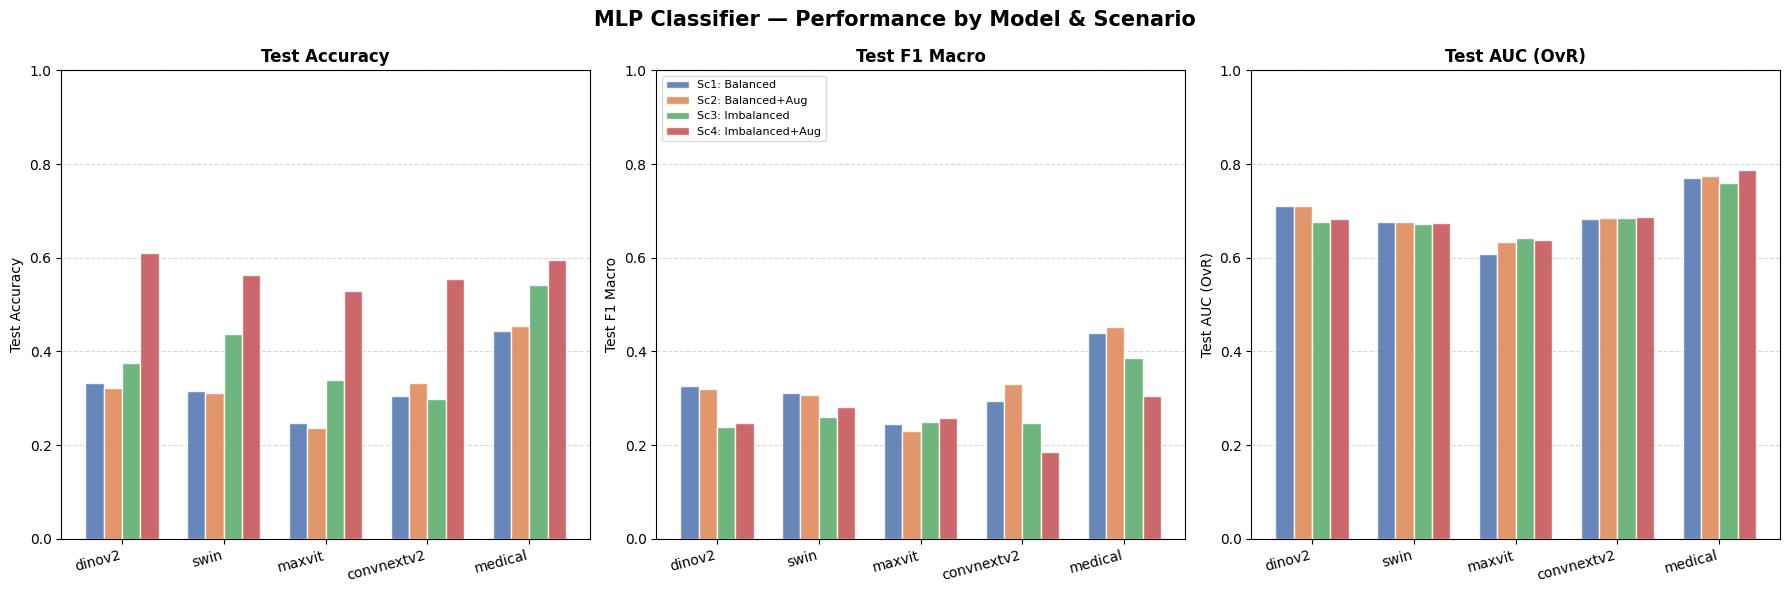

Bar charts saved.


In [ ]:
# ============================================================
# CELL 11 — Visualizations: Bar Charts per Metric
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── Reconstruct summary_df from results (or load CSV if results not in memory)
# If running fresh, load from saved CSV:
# summary_df = pd.read_csv(CKPT_DIR / 'classification_summary.csv')

METRICS = ['Test Acc', 'Test F1 (macro)', 'Test AUC (OvR)']
METRIC_LABELS = ['Test Accuracy', 'Test F1 Macro', 'Test AUC (OvR)']
MODELS = summary_df['Model'].unique()
SCENARIOS = sorted(summary_df['Scenario'].unique())
SCENARIO_LABELS = {
    1: 'Sc1: Balanced',
    2: 'Sc2: Balanced+Aug',
    3: 'Sc3: Imbalanced',
    4: 'Sc4: Imbalanced+Aug',
}
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('MLP Classifier — Performance by Model & Scenario', fontsize=15, fontweight='bold')

x = np.arange(len(MODELS))
width = 0.18

for ax_idx, (metric, label) in enumerate(zip(METRICS, METRIC_LABELS)):
    ax = axes[ax_idx]
    for i, (sc, color) in enumerate(zip(SCENARIOS, COLORS)):
        vals = []
        for model in MODELS:
            row = summary_df[(summary_df['Scenario'] == sc) & (summary_df['Model'] == model)]
            vals.append(row[metric].values[0] if len(row) > 0 else 0)
        bars = ax.bar(x + i * width, vals, width, label=SCENARIO_LABELS[sc], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(MODELS, rotation=15, ha='right', fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(label)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    if ax_idx == 1:
        ax.legend(loc='upper left', fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.savefig(CKPT_DIR / 'bar_charts_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar charts saved.')


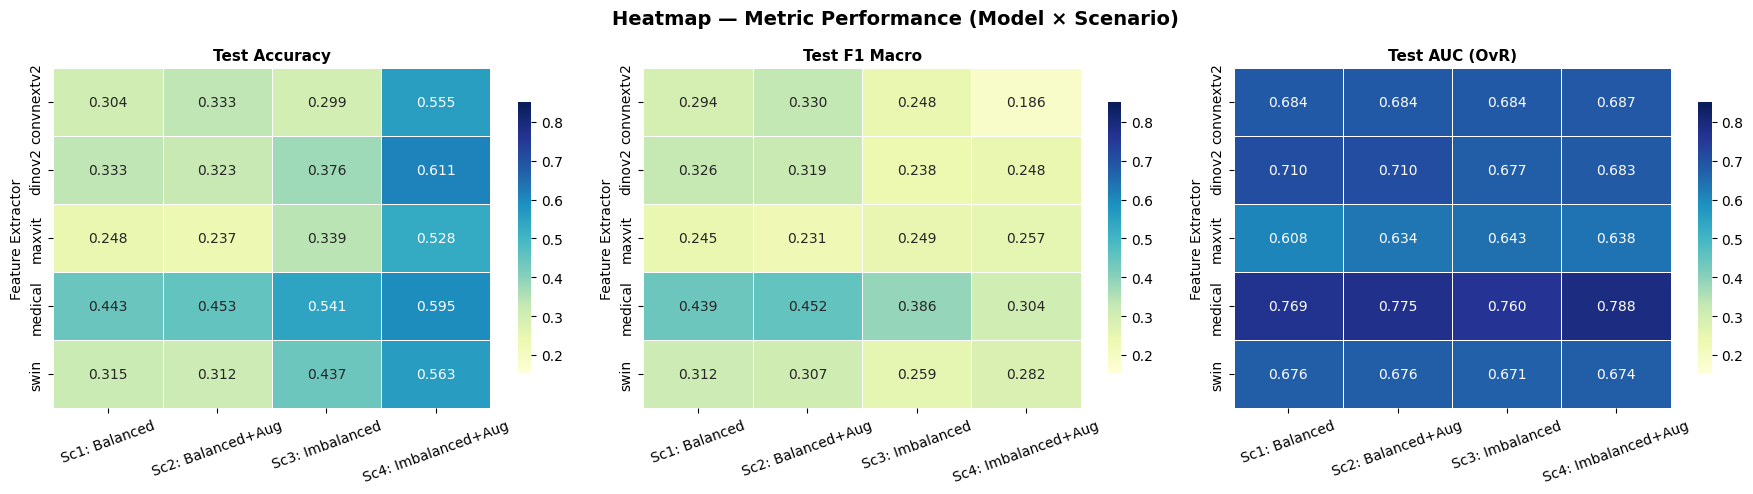

Heatmaps saved.


In [ ]:
# ============================================================
# CELL 12 — Heatmaps: Metric × (Model × Scenario)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Heatmap — Metric Performance (Model × Scenario)', fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes, METRICS, METRIC_LABELS):
    pivot = summary_df.pivot(index='Model', columns='Scenario', values=metric)
    pivot.columns = [SCENARIO_LABELS[c] for c in pivot.columns]
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.3f', cmap='YlGnBu',
        linewidths=0.5, linecolor='white',
        vmin=0.15, vmax=0.85,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Feature Extractor')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(CKPT_DIR / 'heatmaps_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmaps saved.')


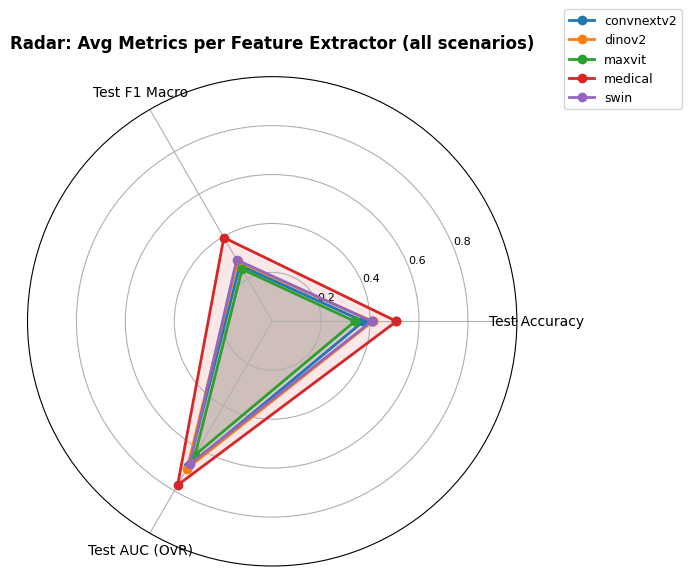

Radar chart saved.


In [ ]:
# ============================================================
# CELL 13 — Radar Chart: Model Profile across all 3 Metrics
#           (averaged across scenarios, shown per model)
# ============================================================

from matplotlib.patches import FancyArrowPatch

model_avg = summary_df.groupby('Model')[METRICS].mean()

categories = METRIC_LABELS
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_title('Radar: Avg Metrics per Feature Extractor (all scenarios)', fontsize=12,
             fontweight='bold', pad=20)

palette = plt.cm.tab10.colors
for idx, (model, row) in enumerate(model_avg.iterrows()):
    vals = row[METRICS].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=palette[idx])
    ax.fill(angles, vals, alpha=0.1, color=palette[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(CKPT_DIR / 'radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart saved.')


=== CELL 12A — Confusion Matrices ===

  Sc1 | dinov2 | balanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


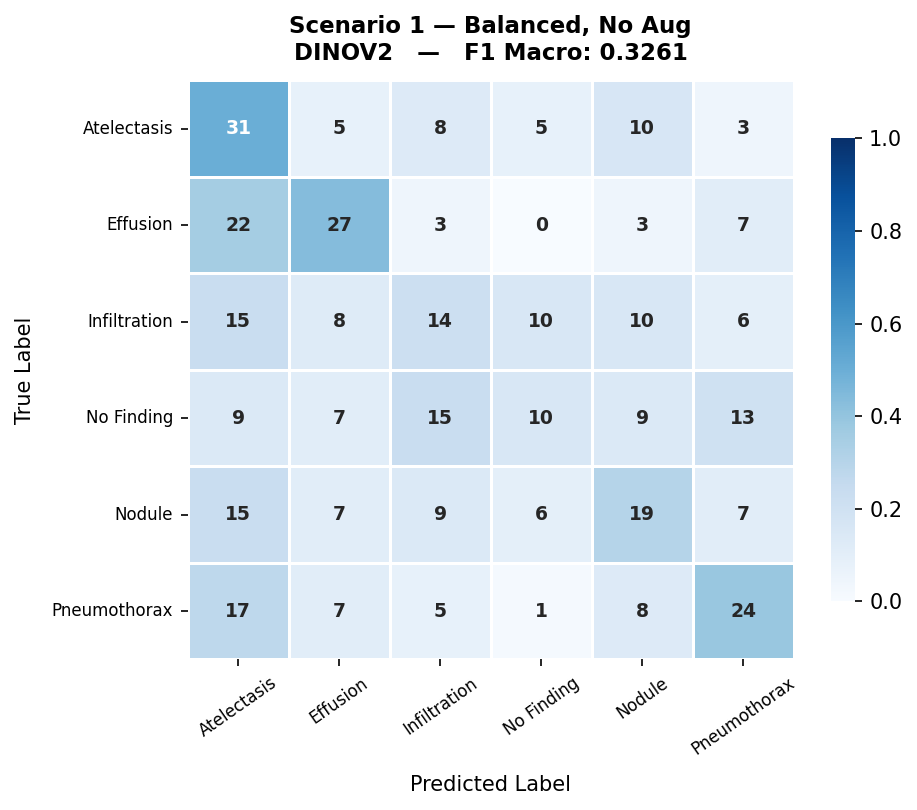

  Saved → cm_sc1_dinov2_balanced.png
  Sc1 | swin | balanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


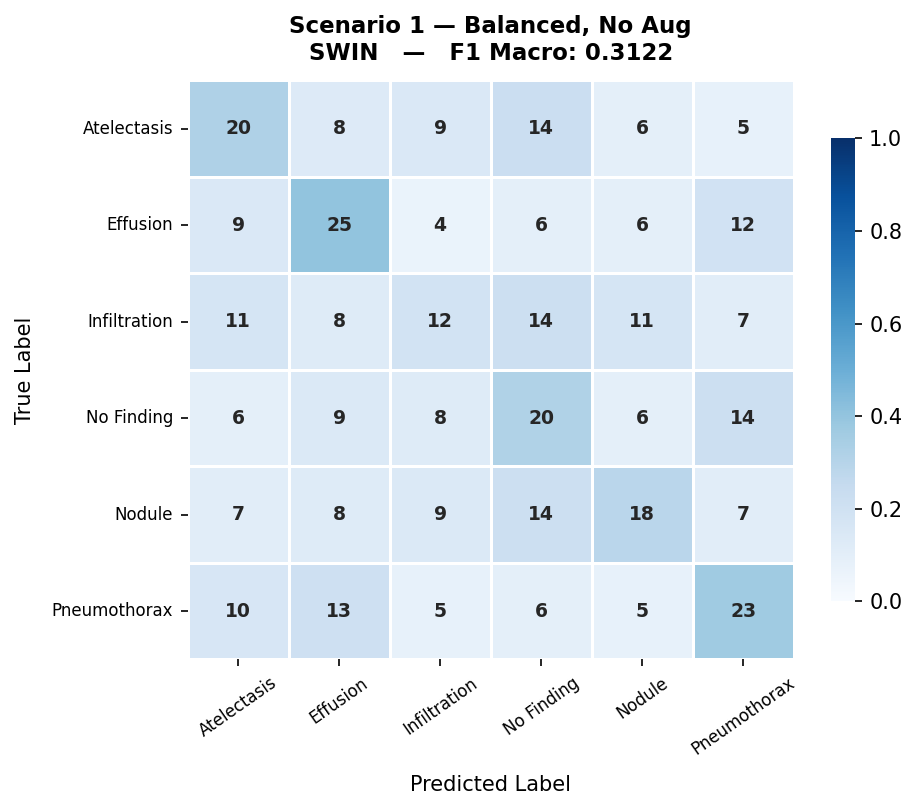

  Saved → cm_sc1_swin_balanced.png
  Sc1 | maxvit | balanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


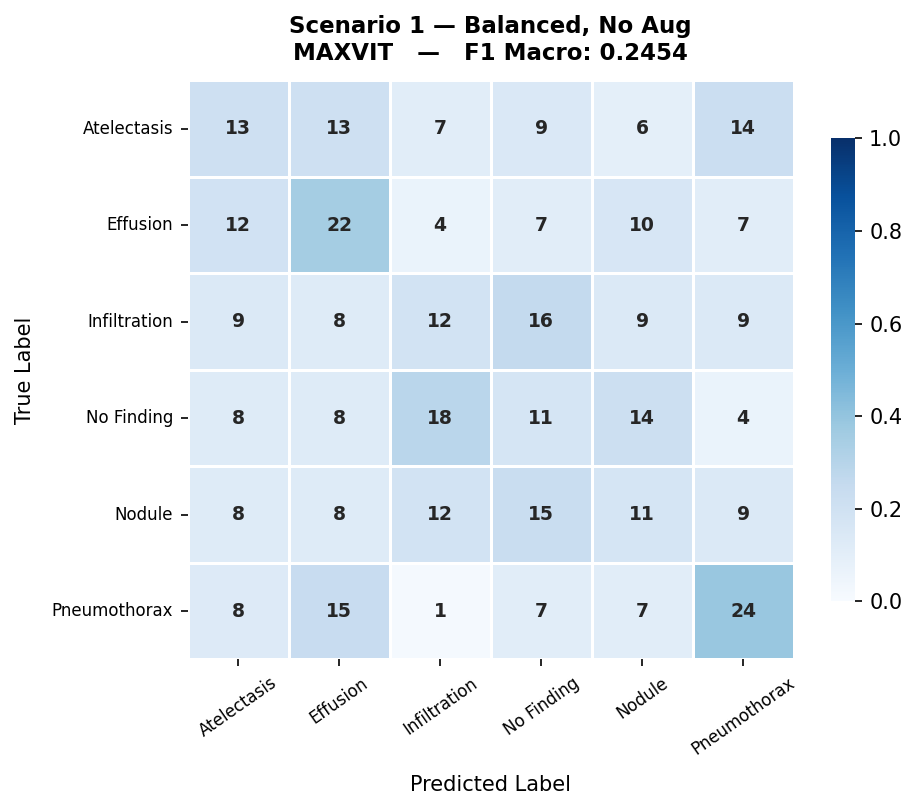

  Saved → cm_sc1_maxvit_balanced.png
  Sc1 | convnextv2 | balanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


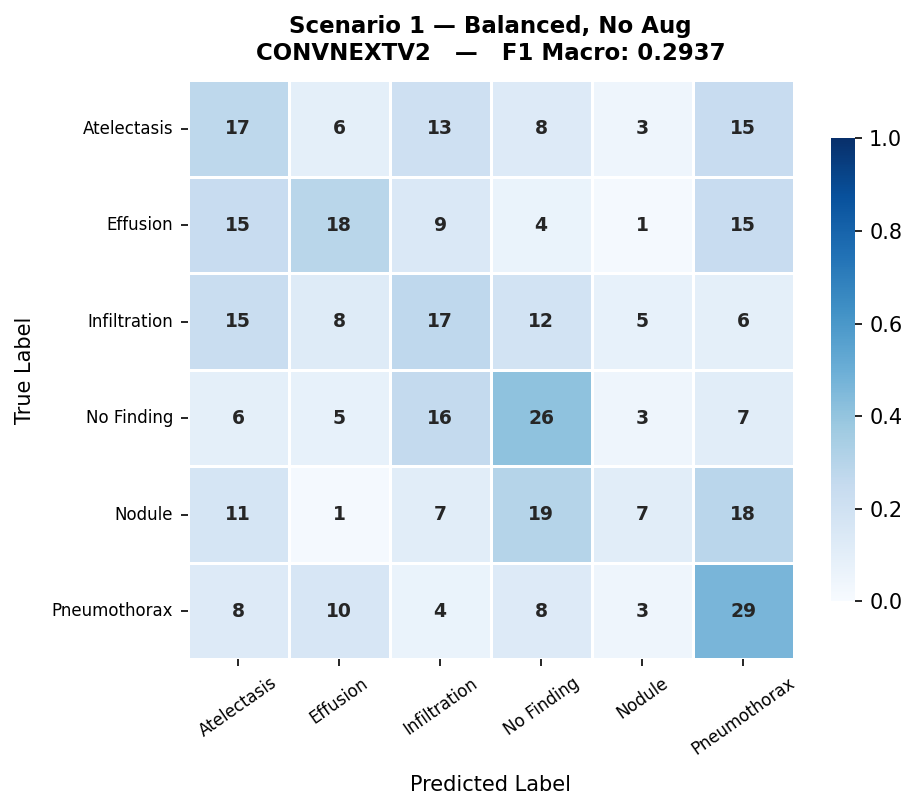

  Saved → cm_sc1_convnextv2_balanced.png
  Sc1 | medical | balanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


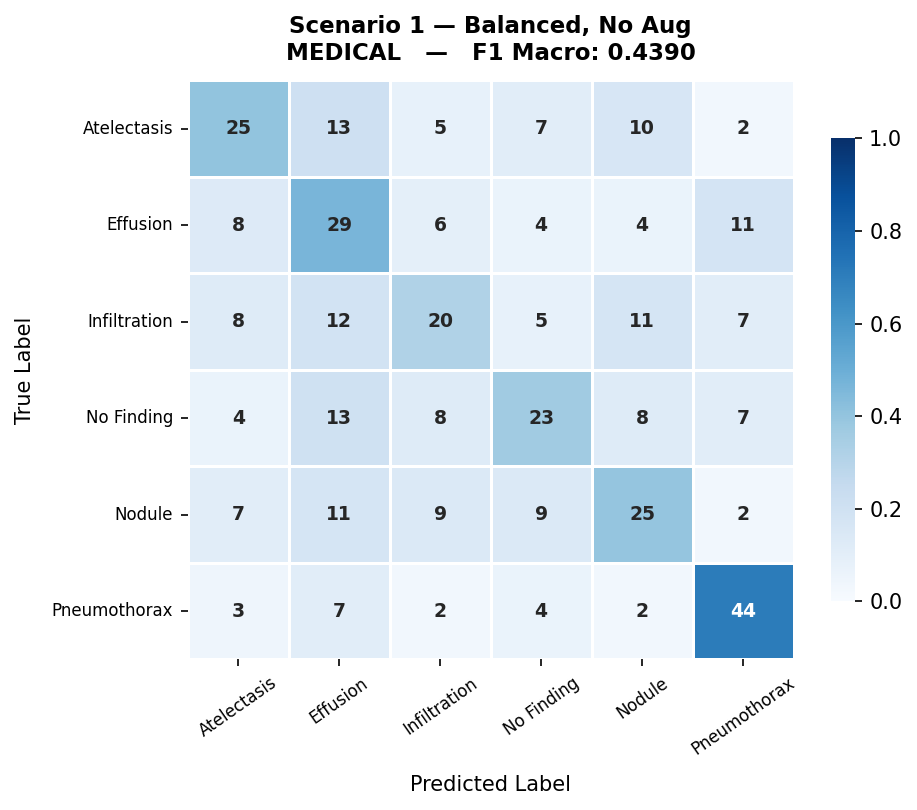

  Saved → cm_sc1_medical_balanced.png
  Sc2 | dinov2 | balanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


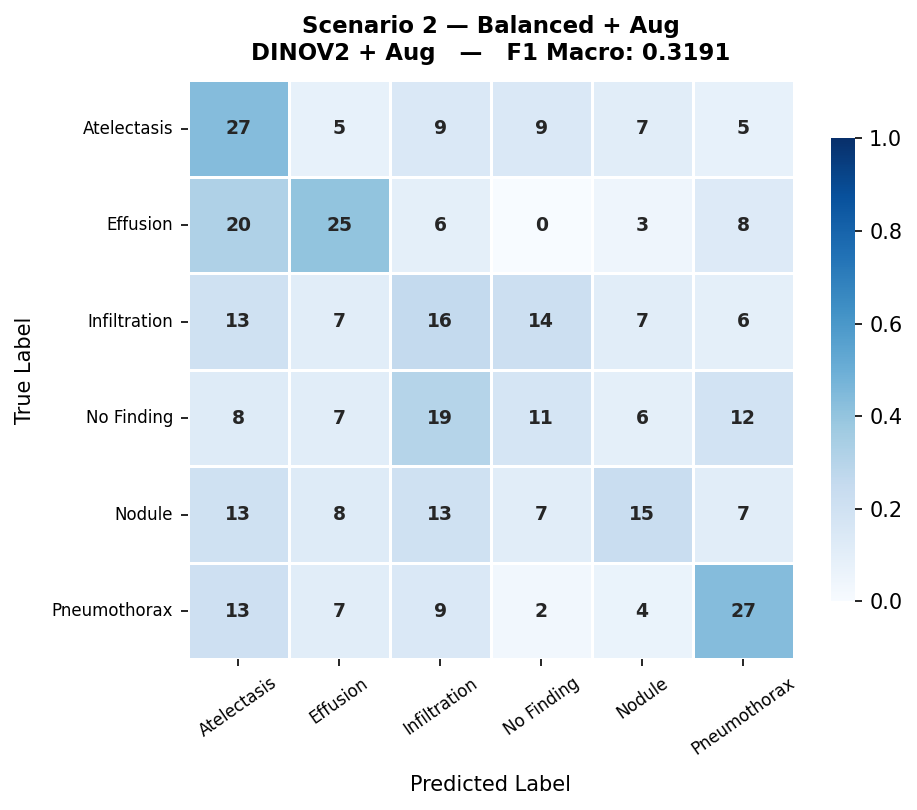

  Saved → cm_sc2_dinov2_balanced_aug.png
  Sc2 | swin | balanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


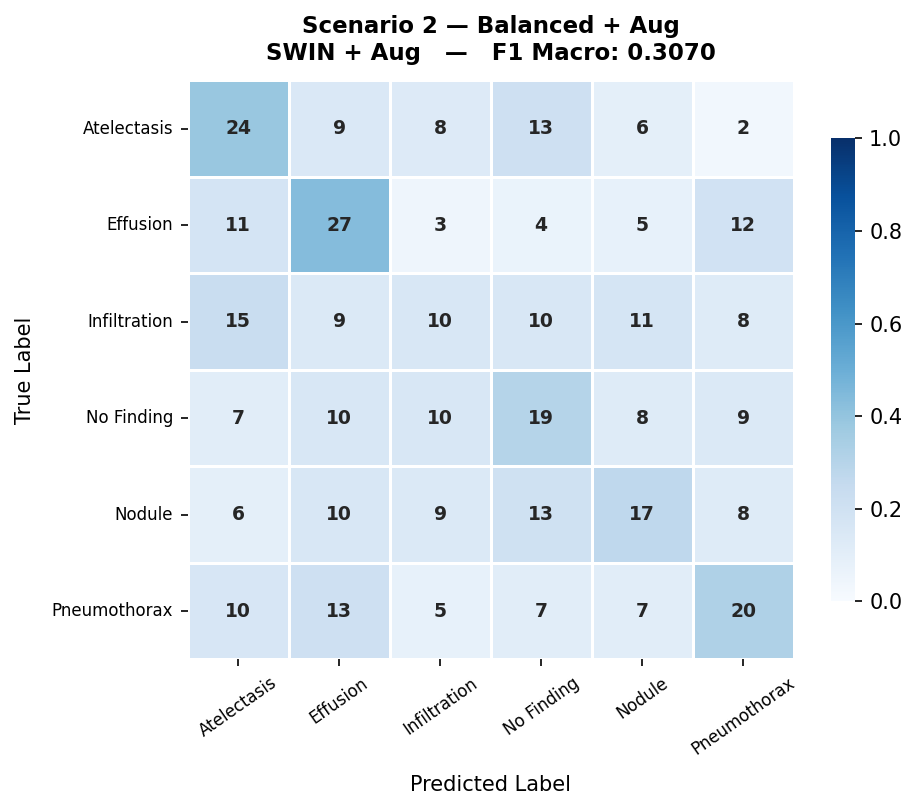

  Saved → cm_sc2_swin_balanced_aug.png
  Sc2 | maxvit | balanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


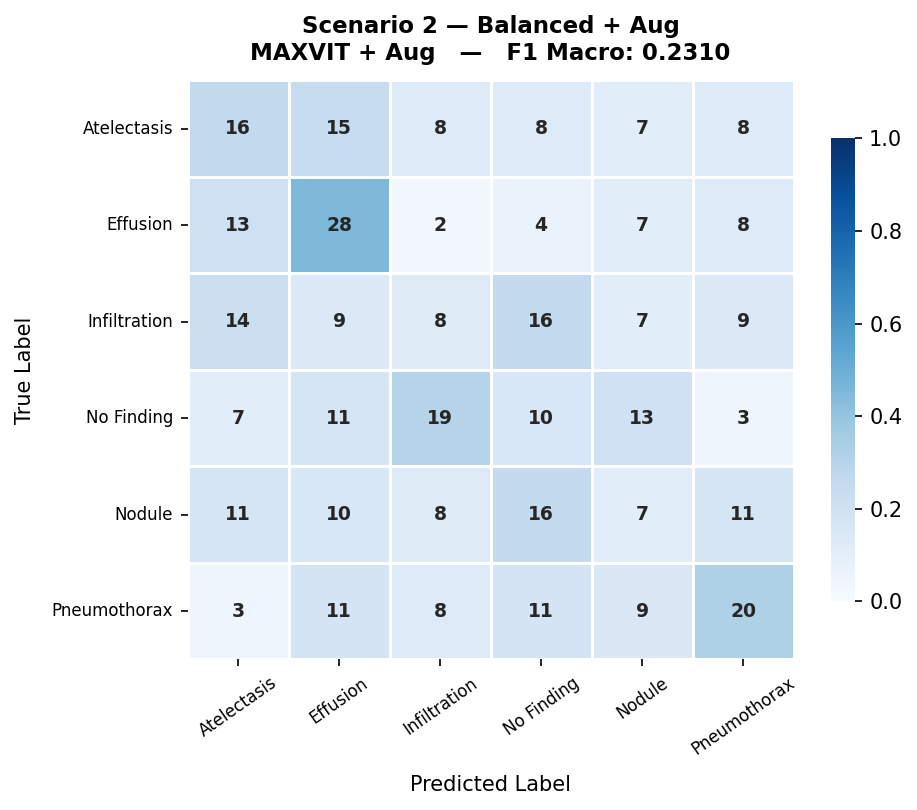

  Saved → cm_sc2_maxvit_balanced_aug.png
  Sc2 | convnextv2 | balanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


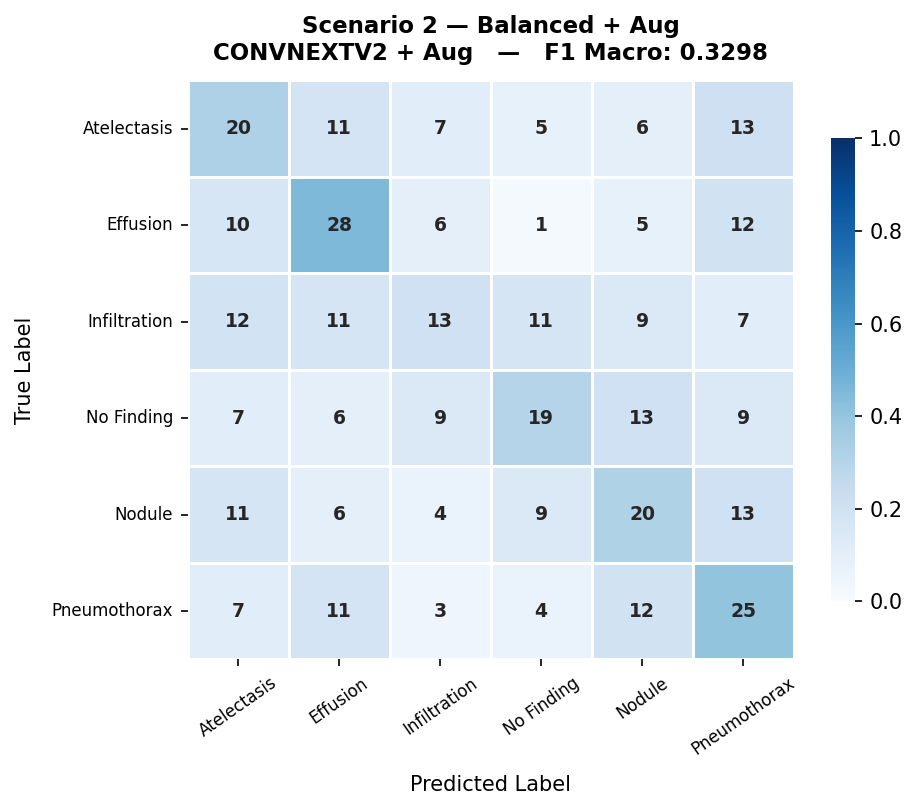

  Saved → cm_sc2_convnextv2_balanced_aug.png
  Sc2 | medical | balanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


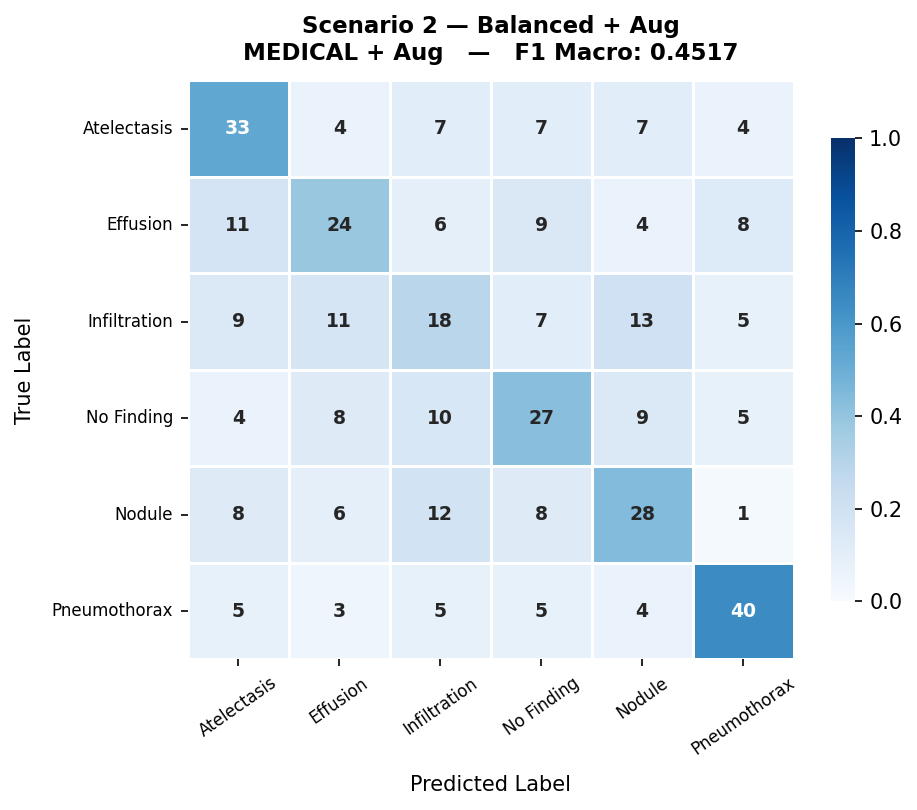

  Saved → cm_sc2_medical_balanced_aug.png
  Sc3 | dinov2 | imbalanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


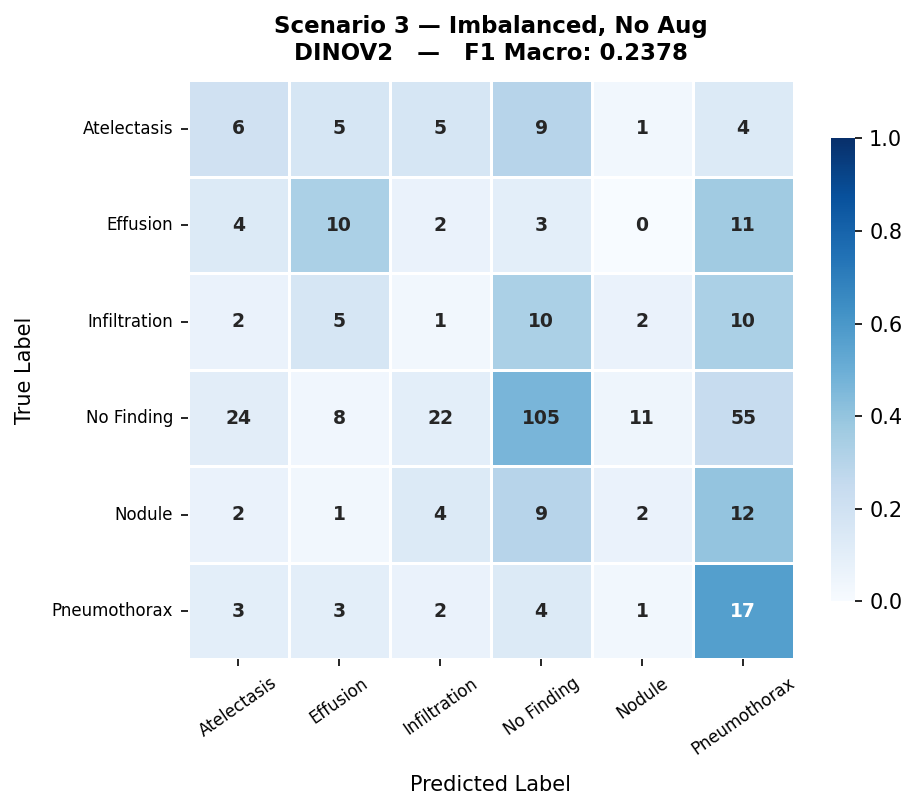

  Saved → cm_sc3_dinov2_imbalanced.png
  Sc3 | swin | imbalanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


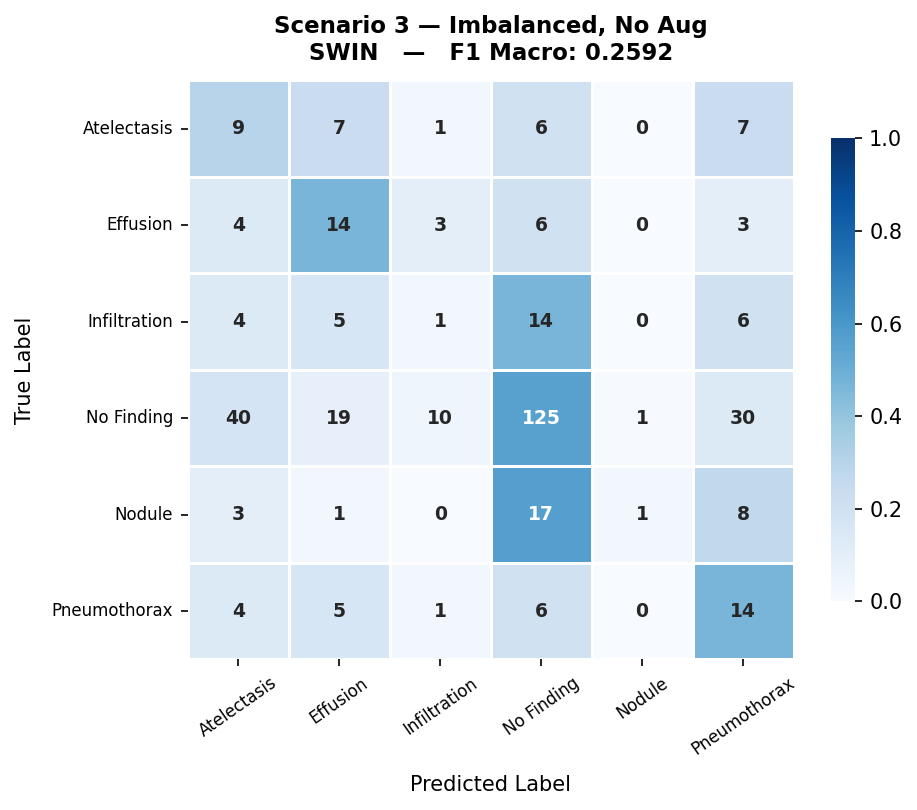

  Saved → cm_sc3_swin_imbalanced.png
  Sc3 | maxvit | imbalanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


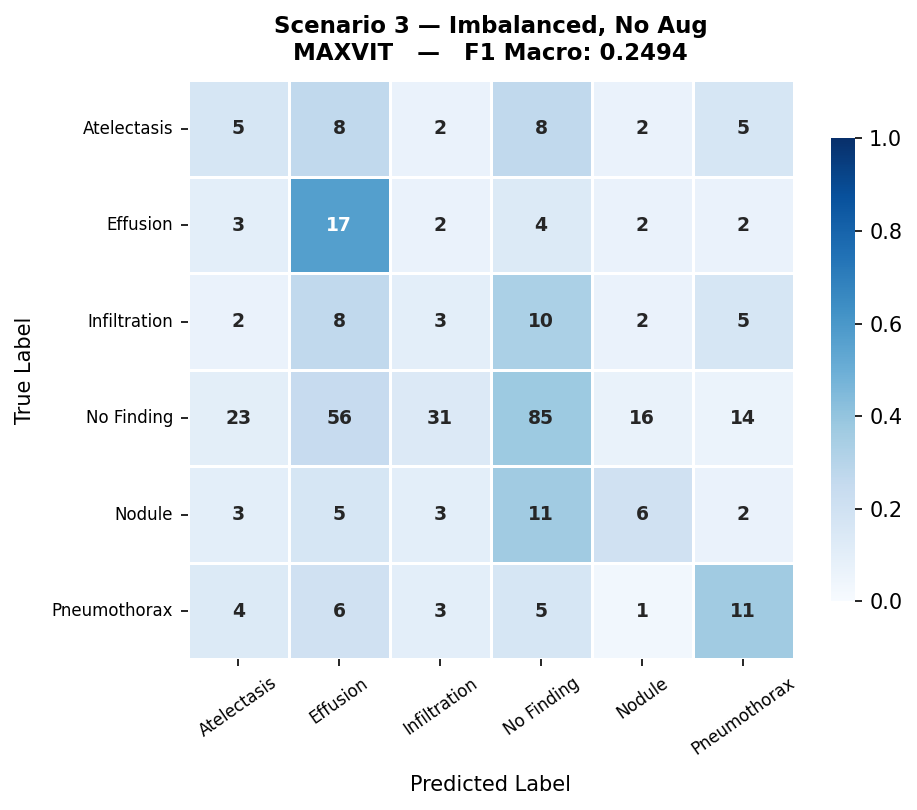

  Saved → cm_sc3_maxvit_imbalanced.png
  Sc3 | convnextv2 | imbalanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


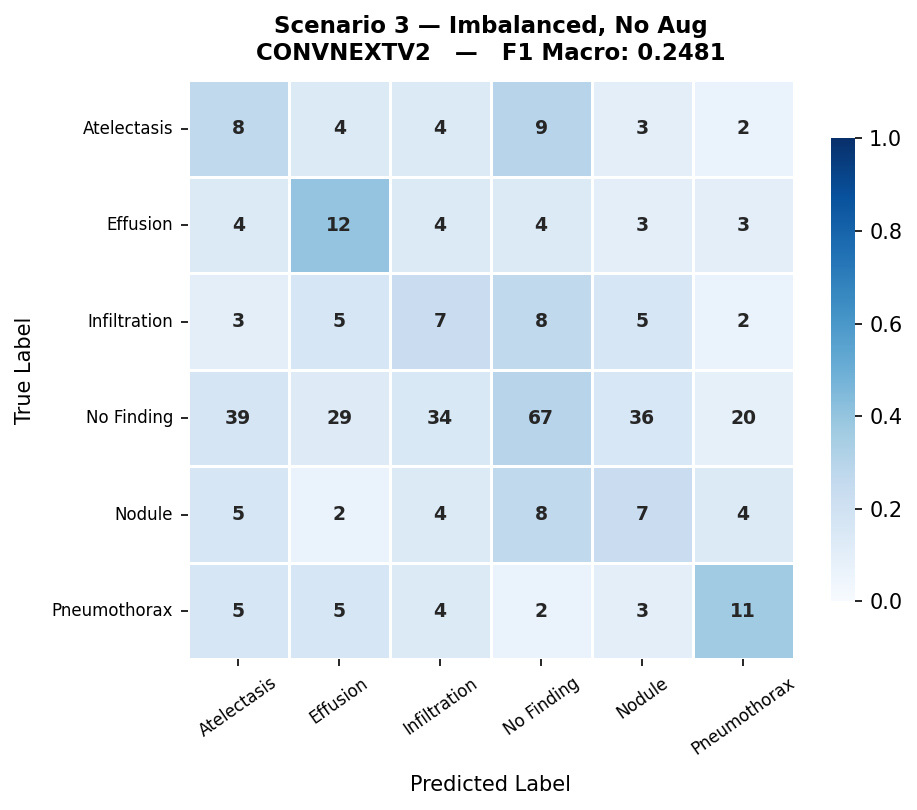

  Saved → cm_sc3_convnextv2_imbalanced.png
  Sc3 | medical | imbalanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


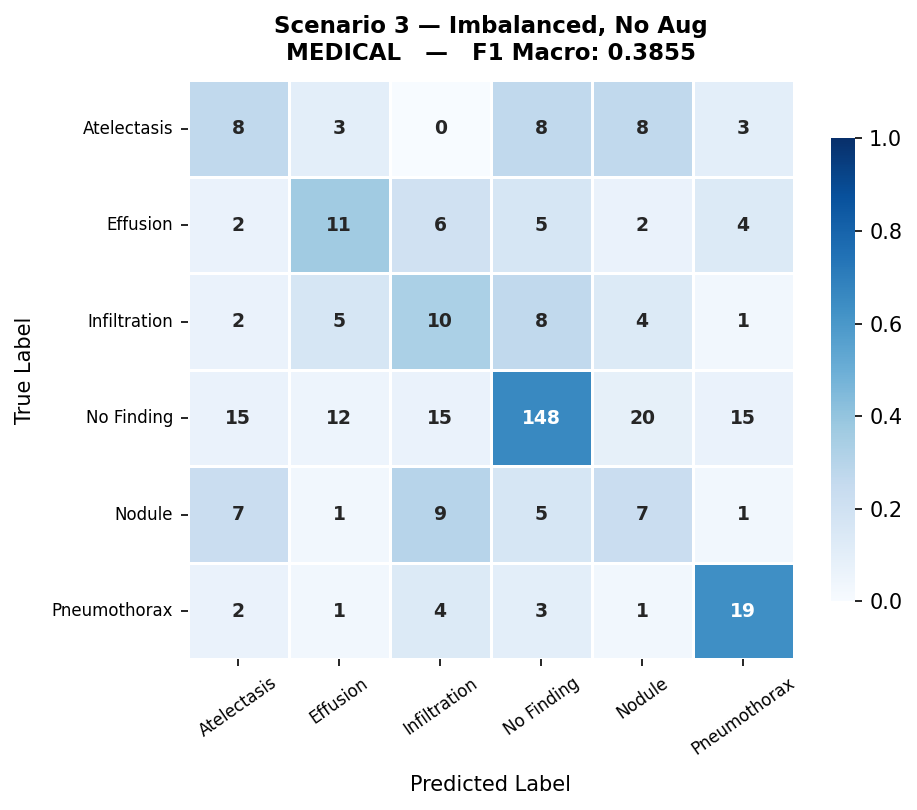

  Saved → cm_sc3_medical_imbalanced.png
  Sc4 | dinov2 | imbalanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


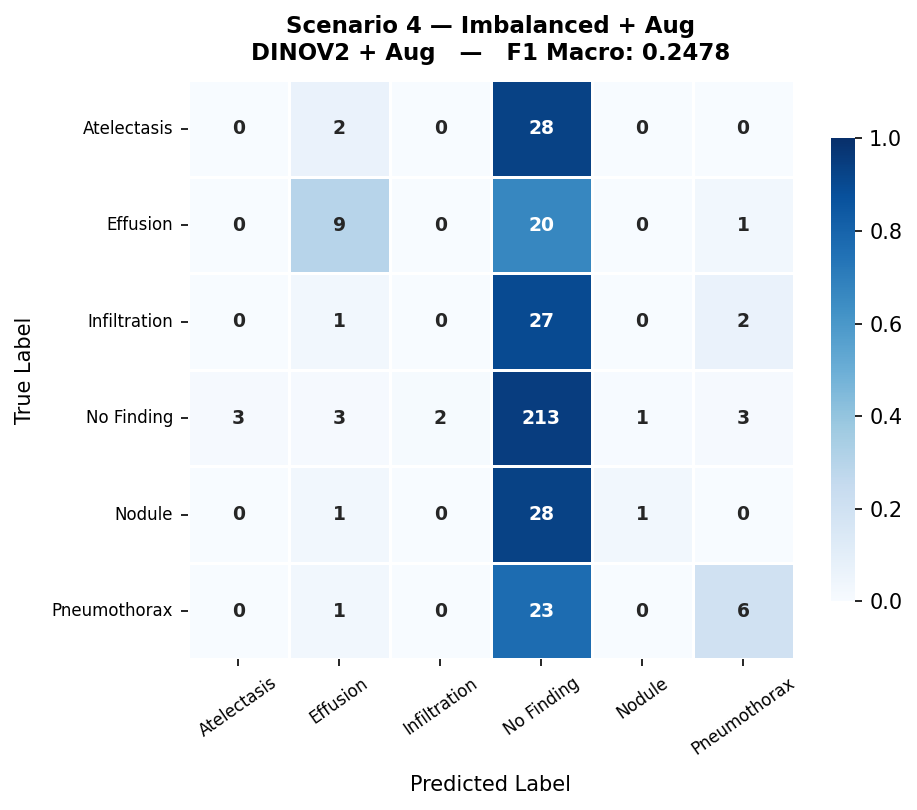

  Saved → cm_sc4_dinov2_imbalanced_aug.png
  Sc4 | swin | imbalanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


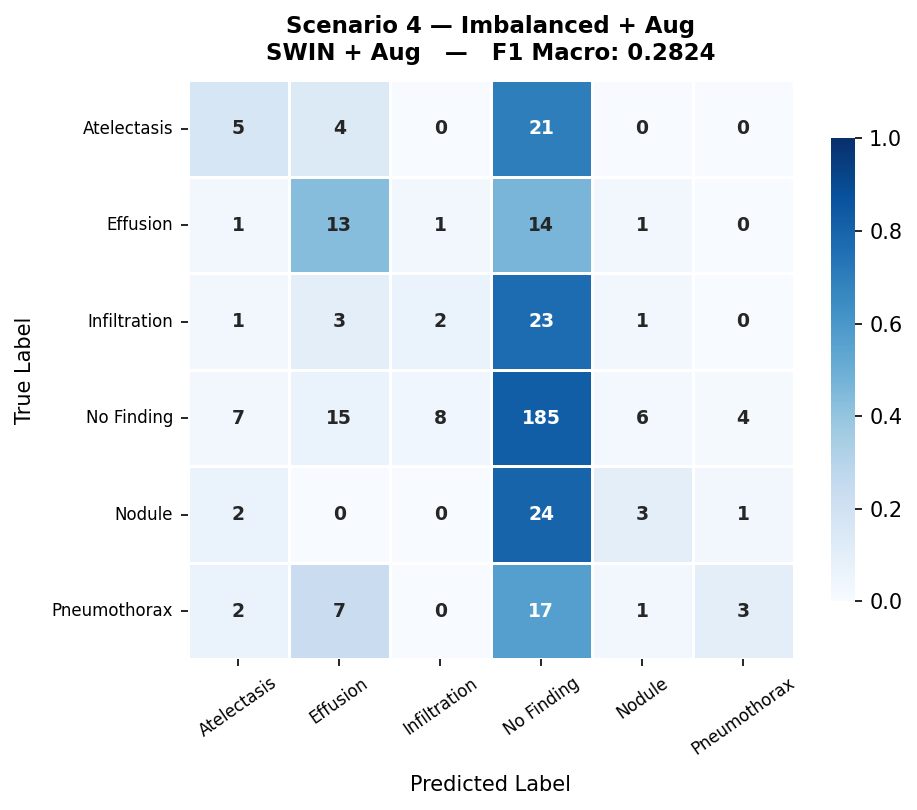

  Saved → cm_sc4_swin_imbalanced_aug.png
  Sc4 | maxvit | imbalanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


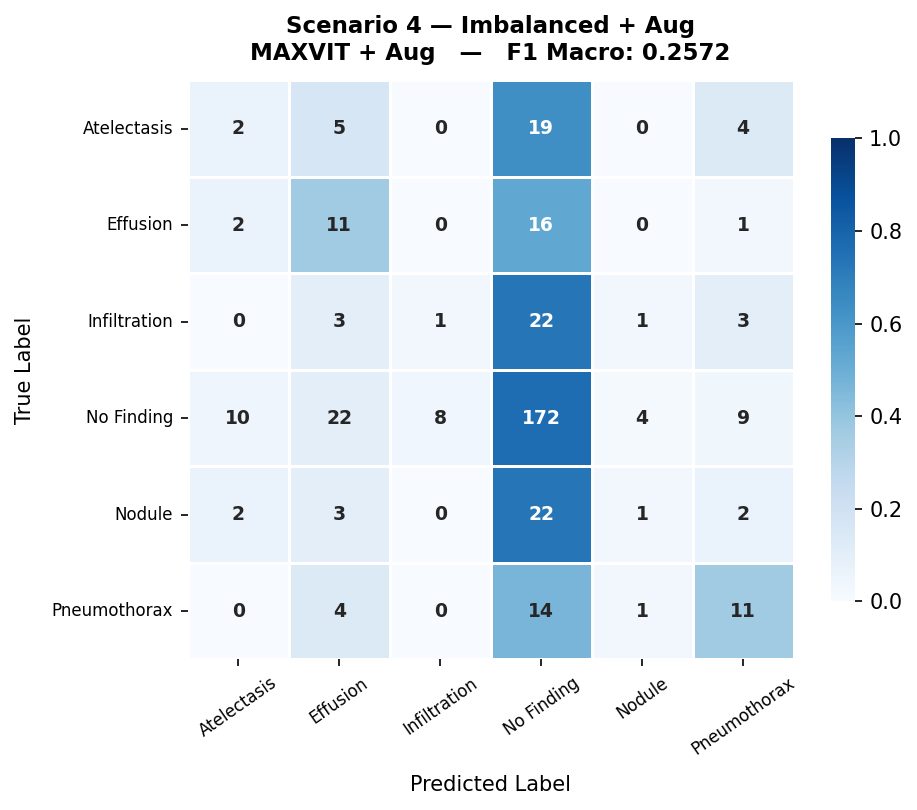

  Saved → cm_sc4_maxvit_imbalanced_aug.png
  Sc4 | convnextv2 | imbalanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


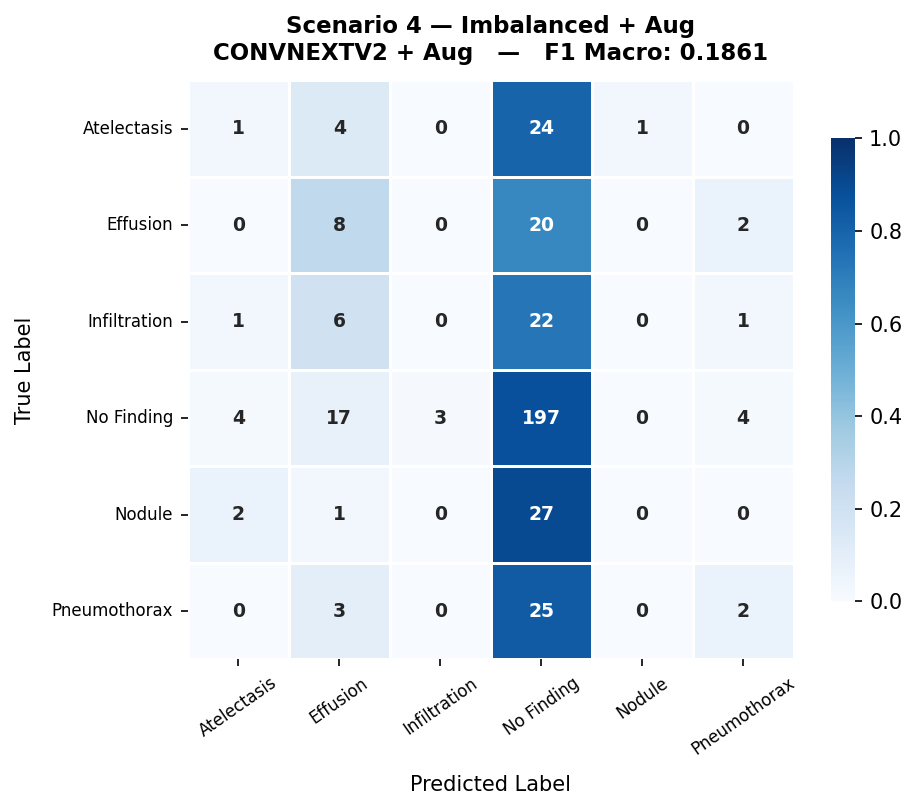

  Saved → cm_sc4_convnextv2_imbalanced_aug.png
  Sc4 | medical | imbalanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


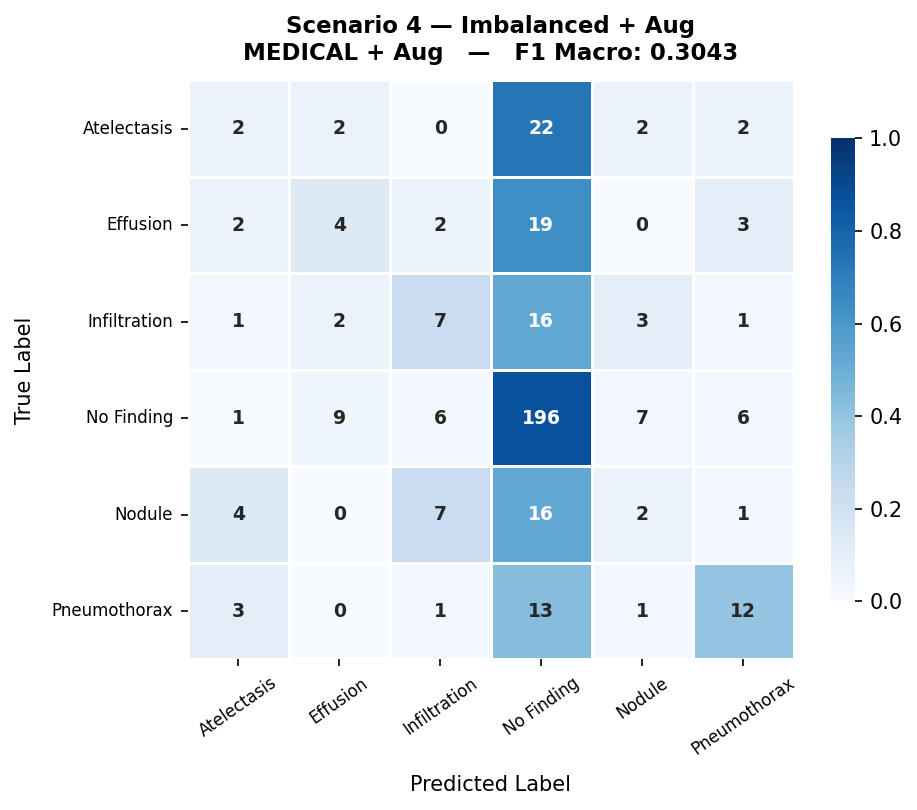

  Saved → cm_sc4_medical_imbalanced_aug.png

Done — semua CM tersimpan di: /content/drive/MyDrive/FP_Admin_KCV/fp/checkpoints


In [ ]:
# ============================================================
# CELL 12A — Confusion Matrix: 1 PNG per (Scenario × Model)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

CLASS_NAMES  = ['Atelectasis', 'Effusion', 'Infiltration',
                'No Finding',  'Nodule',   'Pneumothorax']

SCENARIO_LABELS_CM = {
    1: 'Scenario 1 — Balanced, No Aug',
    2: 'Scenario 2 — Balanced + Aug',
    3: 'Scenario 3 — Imbalanced, No Aug',
    4: 'Scenario 4 — Imbalanced + Aug',
}

EXPERIMENT_GRID = [
    (1, 'dinov2',     'balanced',   False),
    (1, 'swin',       'balanced',   False),
    (1, 'maxvit',     'balanced',   False),
    (1, 'convnextv2', 'balanced',   False),
    (1, 'medical',    'balanced',   False),
    (2, 'dinov2',     'balanced',   True),
    (2, 'swin',       'balanced',   True),
    (2, 'maxvit',     'balanced',   True),
    (2, 'convnextv2', 'balanced',   True),
    (2, 'medical',    'balanced',   True),
    (3, 'dinov2',     'imbalanced', False),
    (3, 'swin',       'imbalanced', False),
    (3, 'maxvit',     'imbalanced', False),
    (3, 'convnextv2', 'imbalanced', False),
    (3, 'medical',    'imbalanced', False),
    (4, 'dinov2',     'imbalanced', True),
    (4, 'swin',       'imbalanced', True),
    (4, 'maxvit',     'imbalanced', True),
    (4, 'convnextv2', 'imbalanced', True),
    (4, 'medical',    'imbalanced', True),
]


# ── Helper: inference ─────────────────────────────────────────

@torch.no_grad()
def get_preds_from_ckpt(scenario_num, fe_tag, split_tag, use_aug):
    csv_path = CSV_MAP.get((fe_tag, split_tag))
    if csv_path is None or not csv_path.exists():
        return None, None

    aug_label = '+aug' if use_aug else ''
    ckpt_path = CKPT_DIR / f'sc{scenario_num}_{fe_tag}_{split_tag}{aug_label}_best.pt'
    if not ckpt_path.exists():
        print(f'  [SKIP] {ckpt_path.name}')
        return None, None

    _, _, test_ds, _, feat_dim = load_csv_splits(csv_path)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                             shuffle=False, drop_last=False)

    model = MLPClassifier(feat_dim).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    all_preds, all_labels = [], []
    for x, y in test_loader:
        logits = model(x.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu())
        all_labels.append(y)

    del model; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (torch.cat(all_preds).numpy(),
            torch.cat(all_labels).numpy())


# ── Plot CM saja ──────────────────────────────────────────────

def plot_cm(scenario_num, fe_tag, split_tag, use_aug):
    preds, labels = get_preds_from_ckpt(
        scenario_num, fe_tag, split_tag, use_aug
    )
    if preds is None:
        return

    cm     = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    f1_mac = f1_score(labels, preds, average='macro', zero_division=0)

    # Normalisasi per baris
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cm_norm  = cm.astype(float) / row_sums

    fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=150)

    sns.heatmap(
        cm_norm,
        ax          = ax,
        annot       = cm,
        fmt         = 'd',
        cmap        = 'Blues',
        vmin        = 0.0, vmax = 1.0,
        linewidths  = 0.5,
        linecolor   = 'white',
        cbar_kws    = {'shrink': 0.8},
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        annot_kws   = {'size': 9, 'weight': 'bold'},
    )

    aug_str = ' + Aug' if use_aug else ''
    ax.set_title(
        f'{SCENARIO_LABELS_CM[scenario_num]}\n'
        f'{fe_tag.upper()}{aug_str}   —   F1 Macro: {f1_mac:.4f}',
        fontsize=11, fontweight='bold', pad=10,
    )
    ax.set_xlabel('Predicted Label', fontsize=10, labelpad=8)
    ax.set_ylabel('True Label',      fontsize=10, labelpad=8)
    ax.tick_params(axis='x', labelsize=8, rotation=35)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

    plt.tight_layout()

    aug_file = '_aug' if use_aug else ''
    out_path = CKPT_DIR / f'cm_sc{scenario_num}_{fe_tag}_{split_tag}{aug_file}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'  Saved → {out_path.name}')


# ── Jalankan ──────────────────────────────────────────────────

print('=== CELL 12A — Confusion Matrices ===\n')
for sc_num, fe, split, aug in EXPERIMENT_GRID:
    print(f'  Sc{sc_num} | {fe} | {split} | aug={aug}')
    plot_cm(sc_num, fe, split, aug)

print('\nDone — semua CM tersimpan di:', CKPT_DIR)

=== CELL 12B — F1 Score per Class ===

  Sc1 | dinov2 | balanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


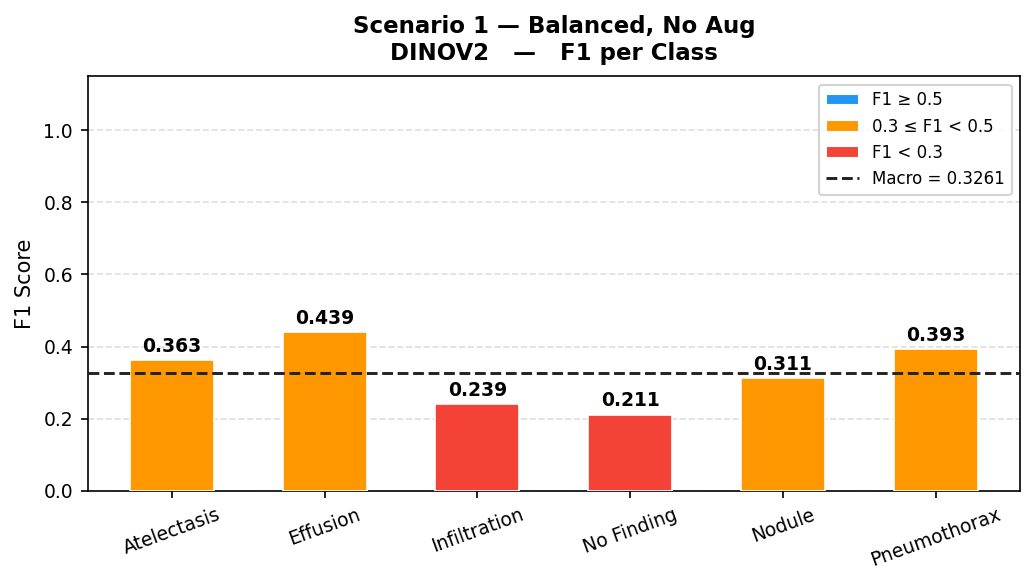

  Saved → f1cls_sc1_dinov2_balanced.png
  Sc1 | swin | balanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


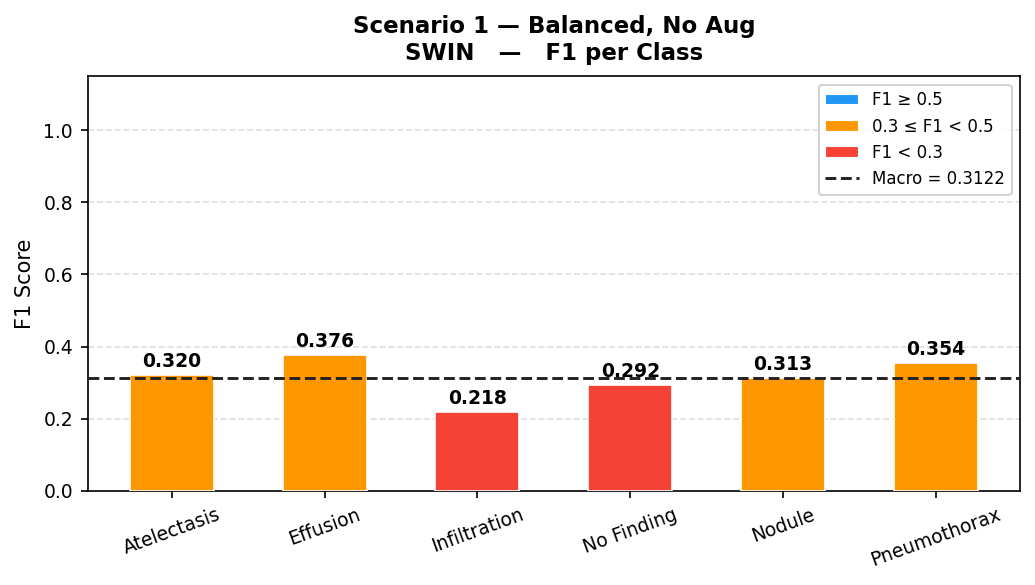

  Saved → f1cls_sc1_swin_balanced.png
  Sc1 | maxvit | balanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


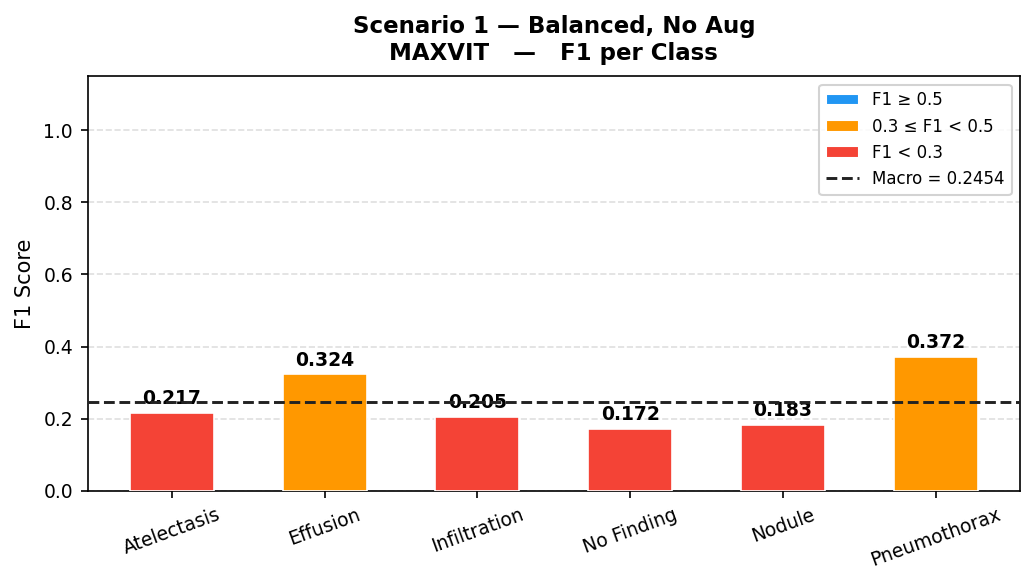

  Saved → f1cls_sc1_maxvit_balanced.png
  Sc1 | convnextv2 | balanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


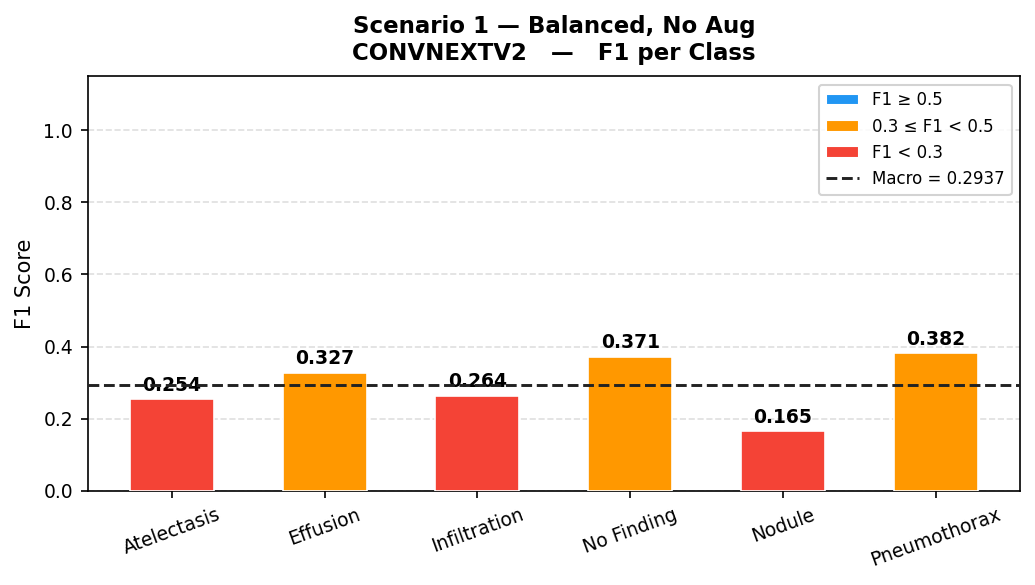

  Saved → f1cls_sc1_convnextv2_balanced.png
  Sc1 | medical | balanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


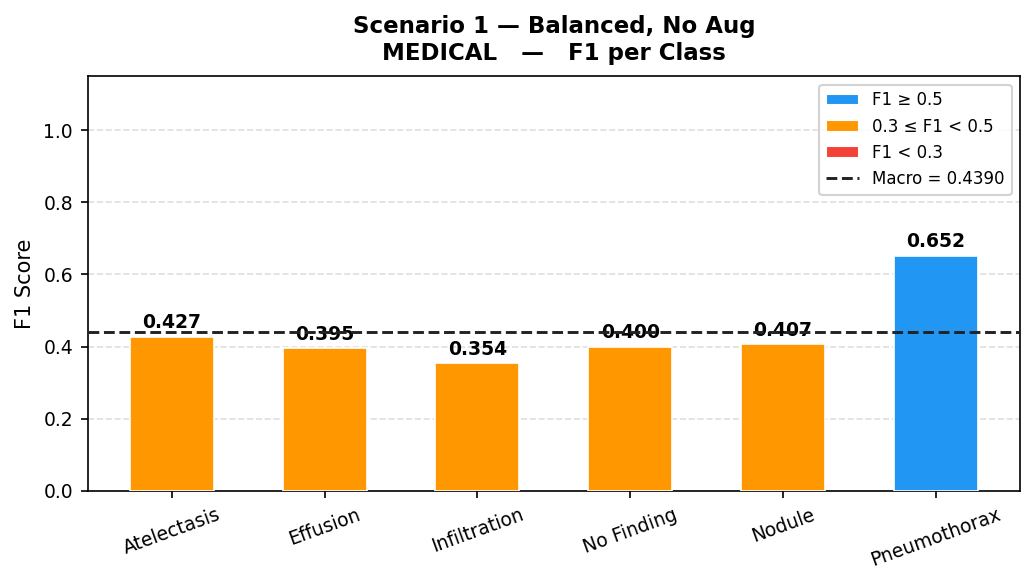

  Saved → f1cls_sc1_medical_balanced.png
  Sc2 | dinov2 | balanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


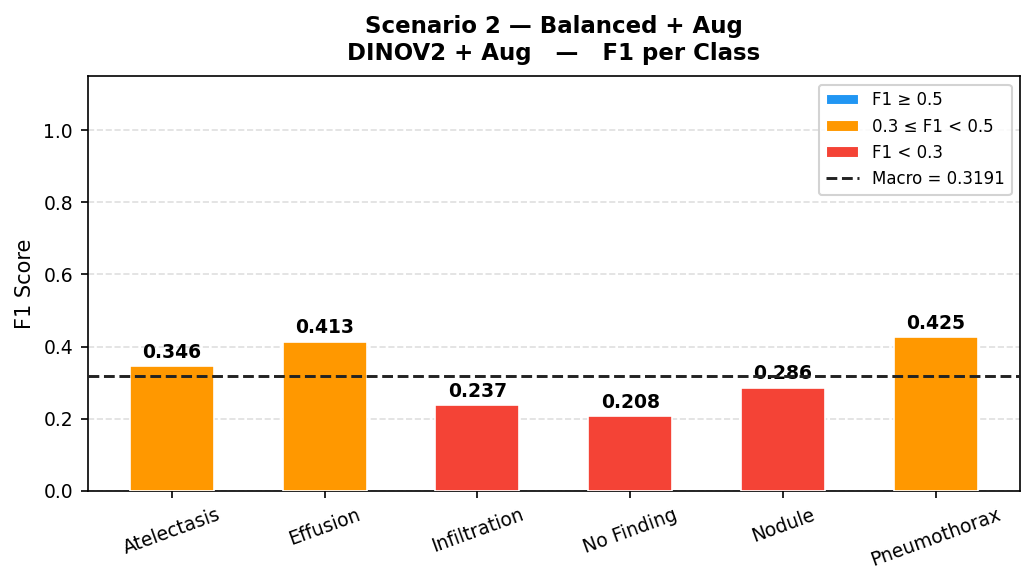

  Saved → f1cls_sc2_dinov2_balanced_aug.png
  Sc2 | swin | balanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


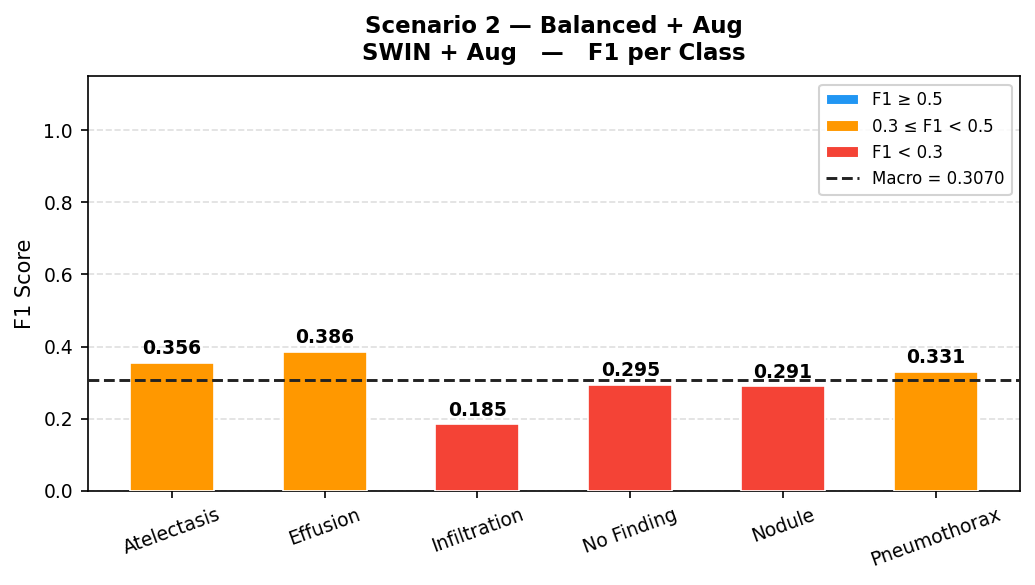

  Saved → f1cls_sc2_swin_balanced_aug.png
  Sc2 | maxvit | balanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


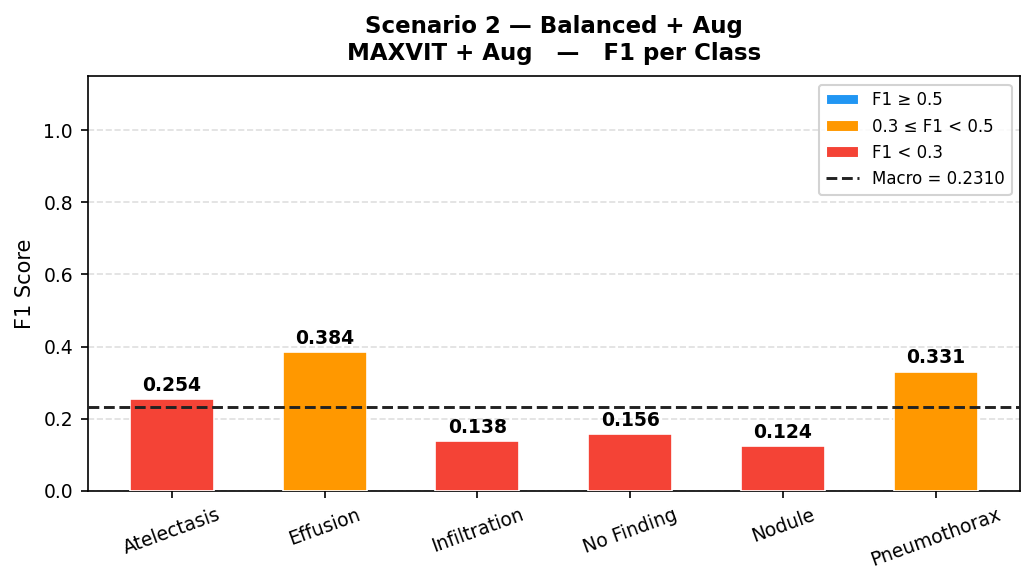

  Saved → f1cls_sc2_maxvit_balanced_aug.png
  Sc2 | convnextv2 | balanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


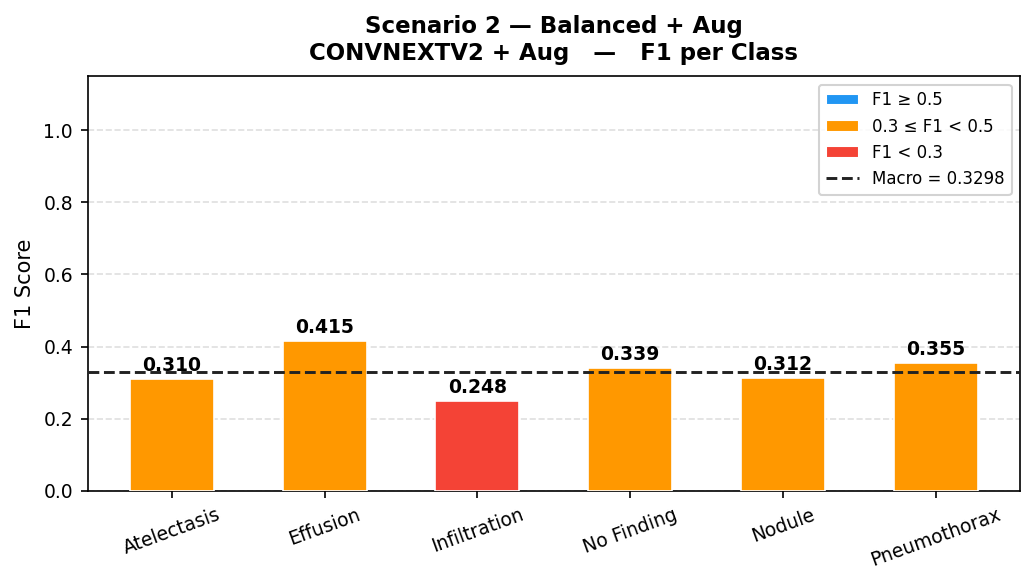

  Saved → f1cls_sc2_convnextv2_balanced_aug.png
  Sc2 | medical | balanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[0.999 0.999 0.999 0.999 1.002 1.002]


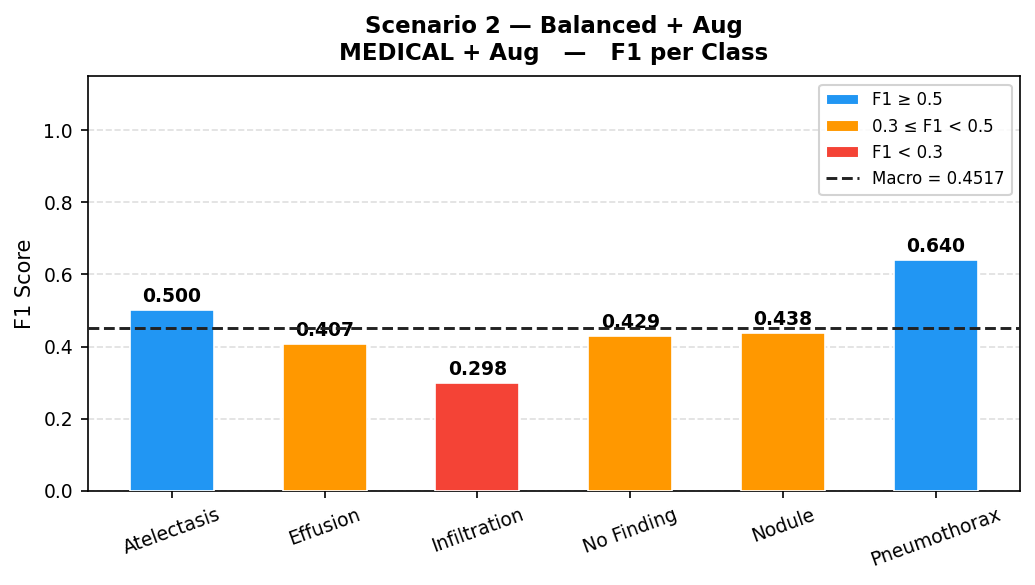

  Saved → f1cls_sc2_medical_balanced_aug.png
  Sc3 | dinov2 | imbalanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


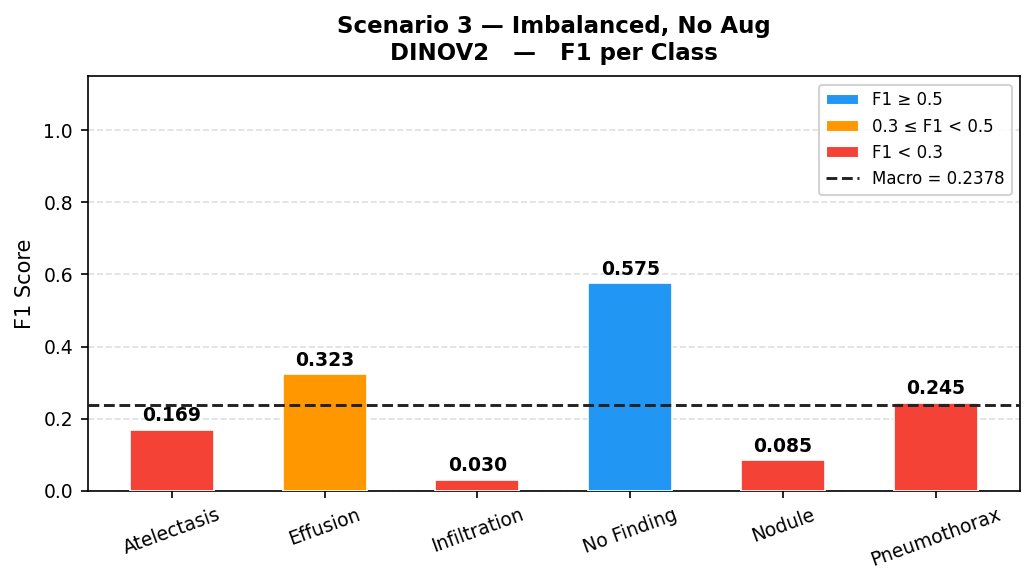

  Saved → f1cls_sc3_dinov2_imbalanced.png
  Sc3 | swin | imbalanced | aug=False
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


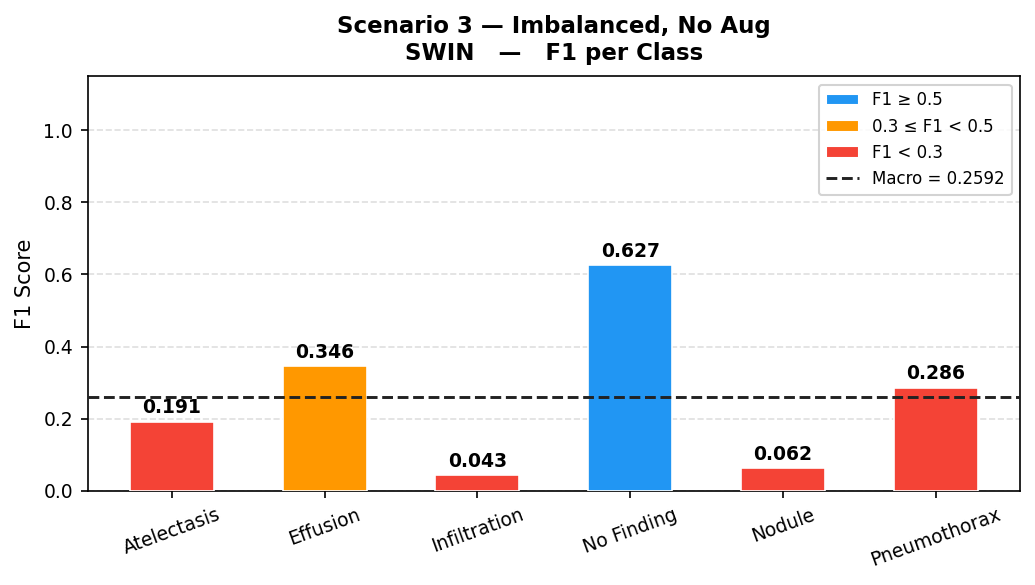

  Saved → f1cls_sc3_swin_imbalanced.png
  Sc3 | maxvit | imbalanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


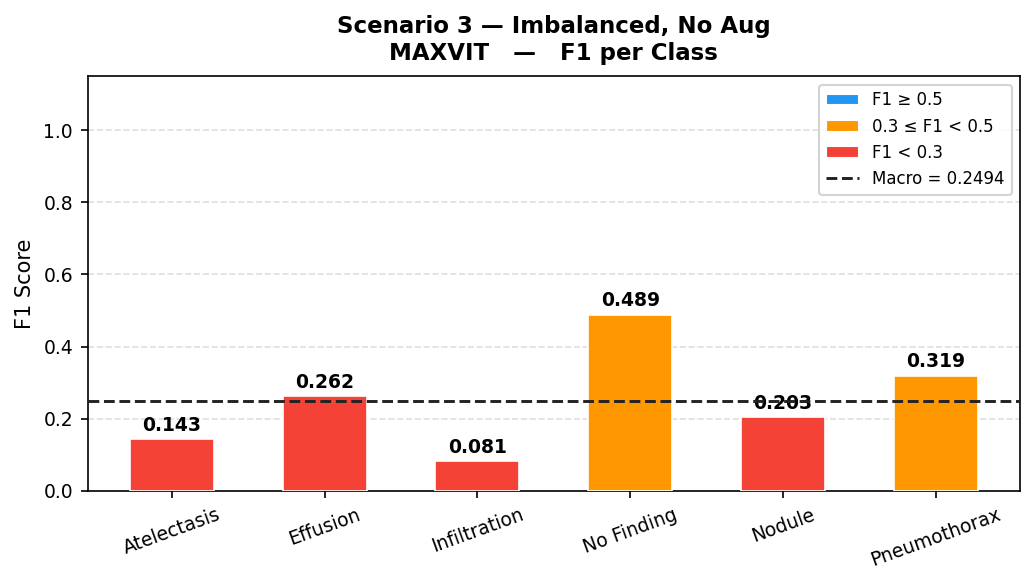

  Saved → f1cls_sc3_maxvit_imbalanced.png
  Sc3 | convnextv2 | imbalanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


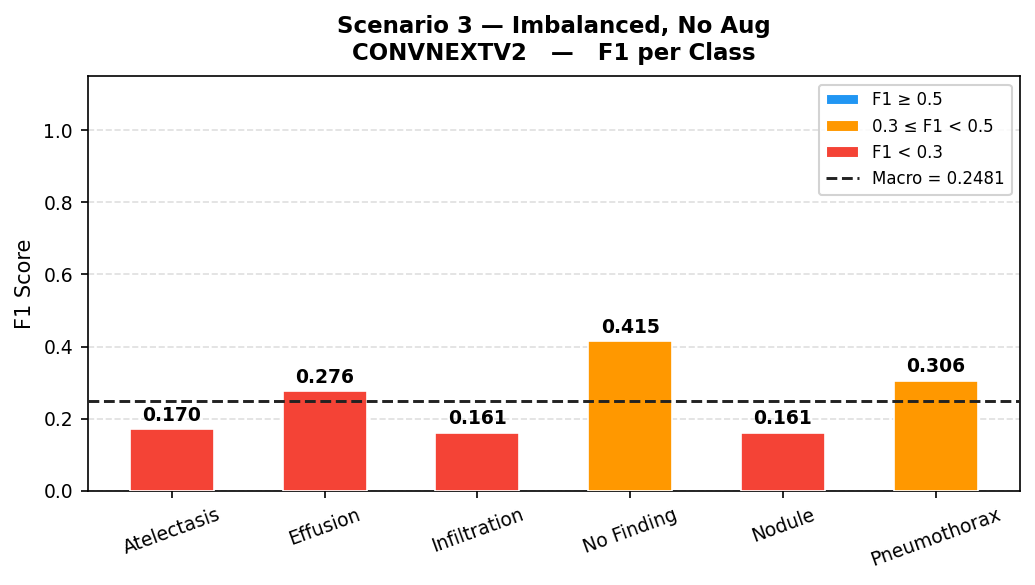

  Saved → f1cls_sc3_convnextv2_imbalanced.png
  Sc3 | medical | imbalanced | aug=False
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


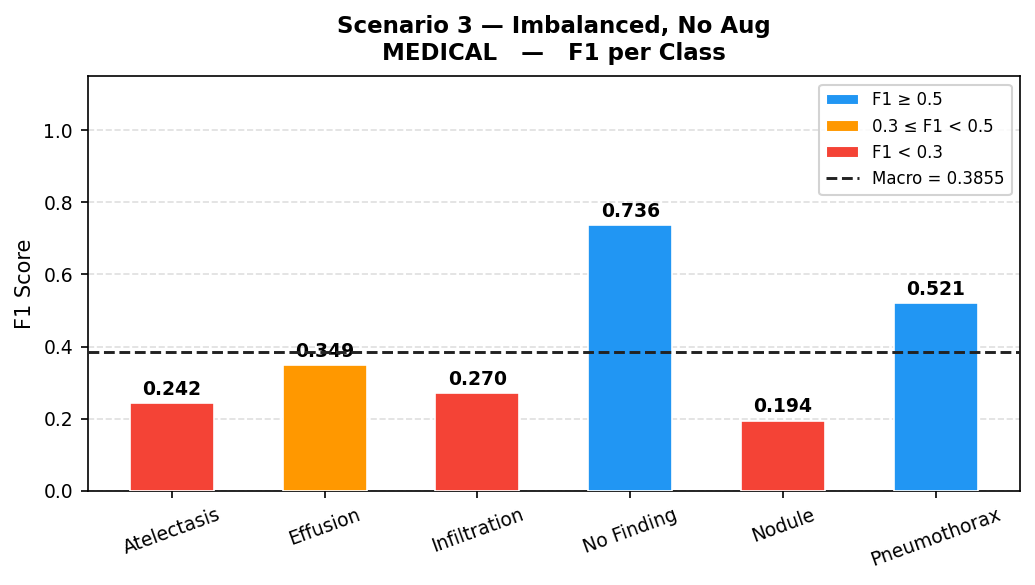

  Saved → f1cls_sc3_medical_imbalanced.png
  Sc4 | dinov2 | imbalanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


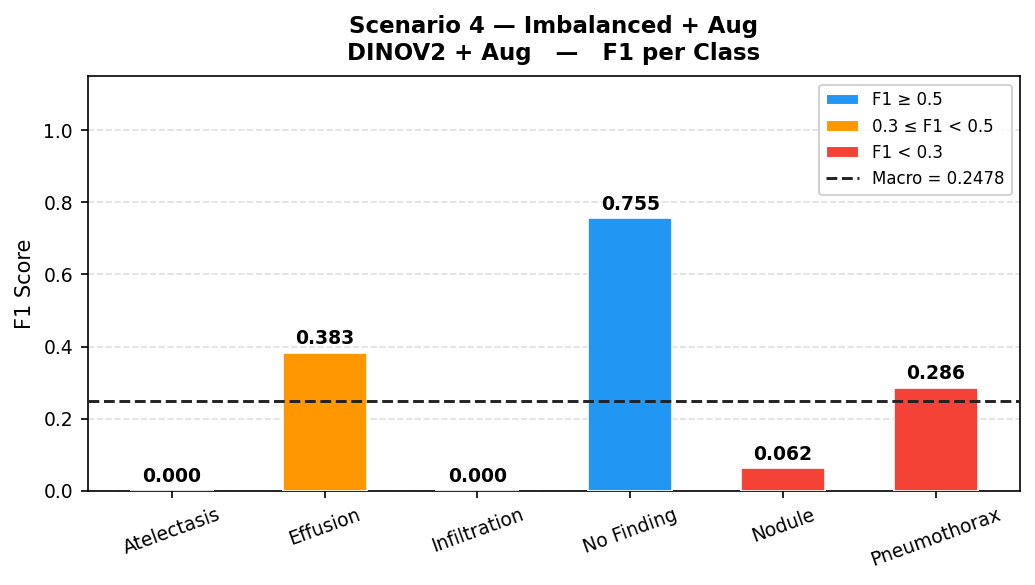

  Saved → f1cls_sc4_dinov2_imbalanced_aug.png
  Sc4 | swin | imbalanced | aug=True
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


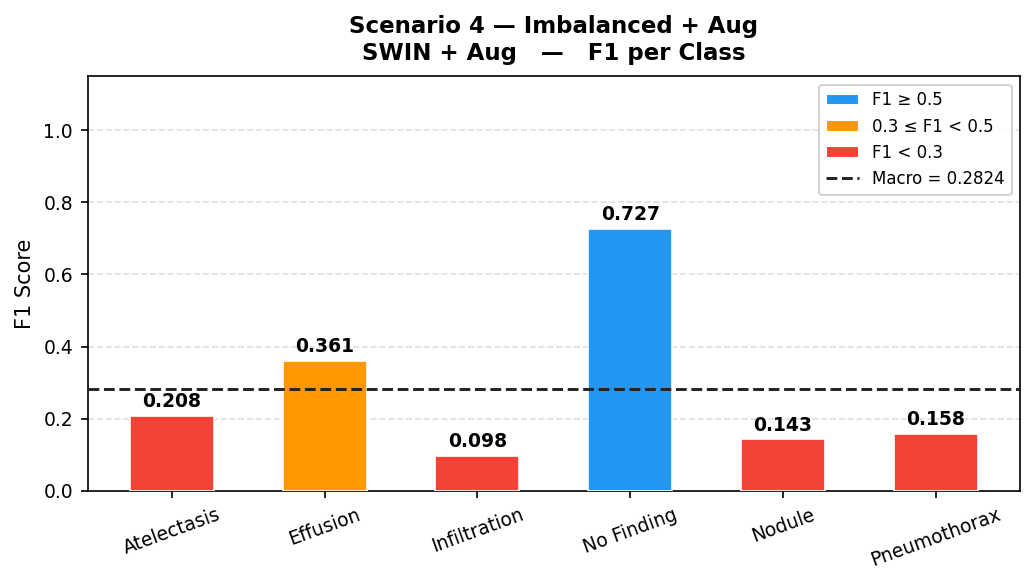

  Saved → f1cls_sc4_swin_imbalanced_aug.png
  Sc4 | maxvit | imbalanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=768  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


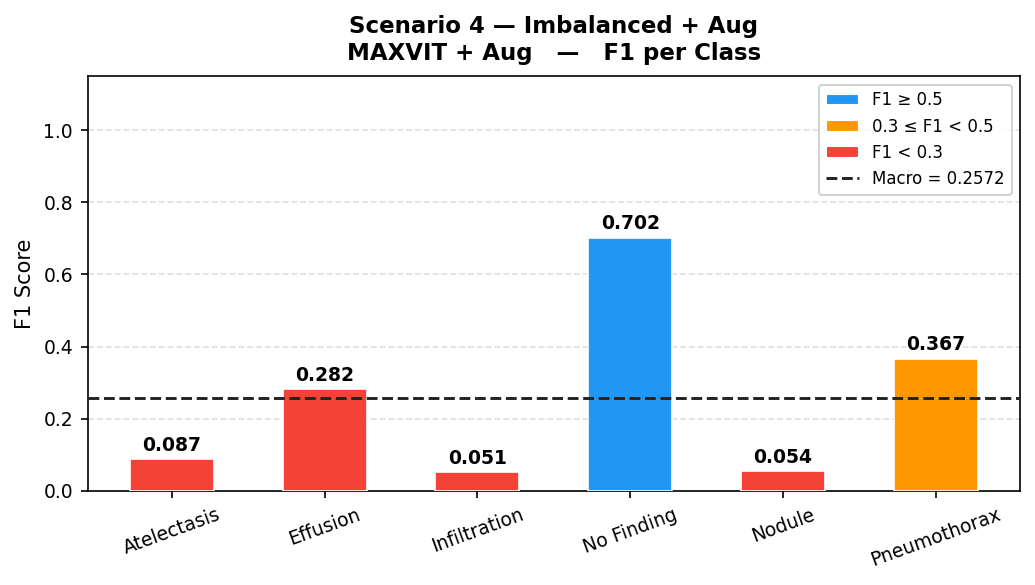

  Saved → f1cls_sc4_maxvit_imbalanced_aug.png
  Sc4 | convnextv2 | imbalanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=1024  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


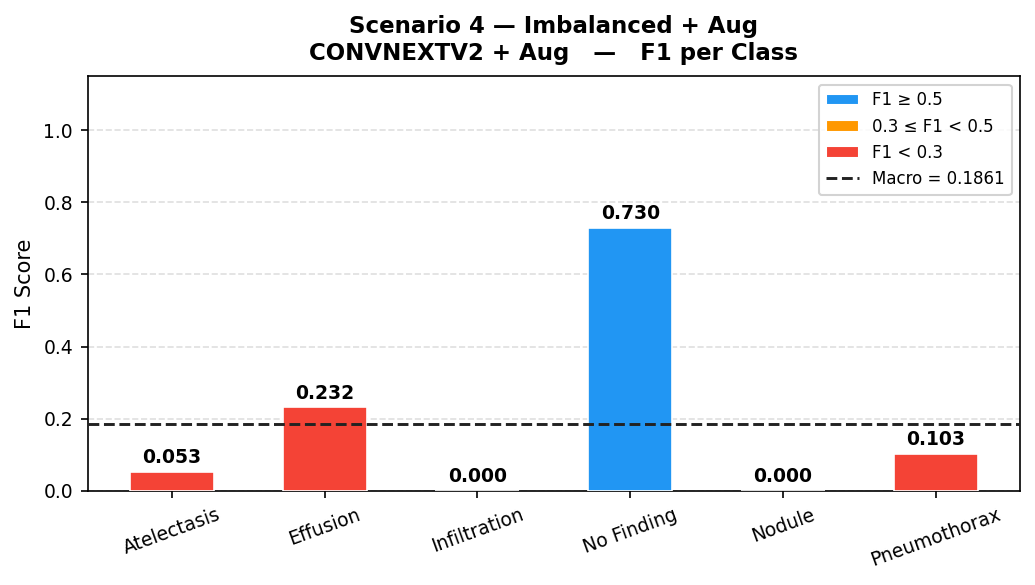

  Saved → f1cls_sc4_convnextv2_imbalanced_aug.png
  Sc4 | medical | imbalanced | aug=True
  Label encoding: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3, 'Nodule': 4, 'Pneumothorax': 5}
  Split → train=1750 | val=375 | test=375
  feat_dim=128  |  class_weights=[2.083 2.083 2.083 0.278 2.083 2.083]


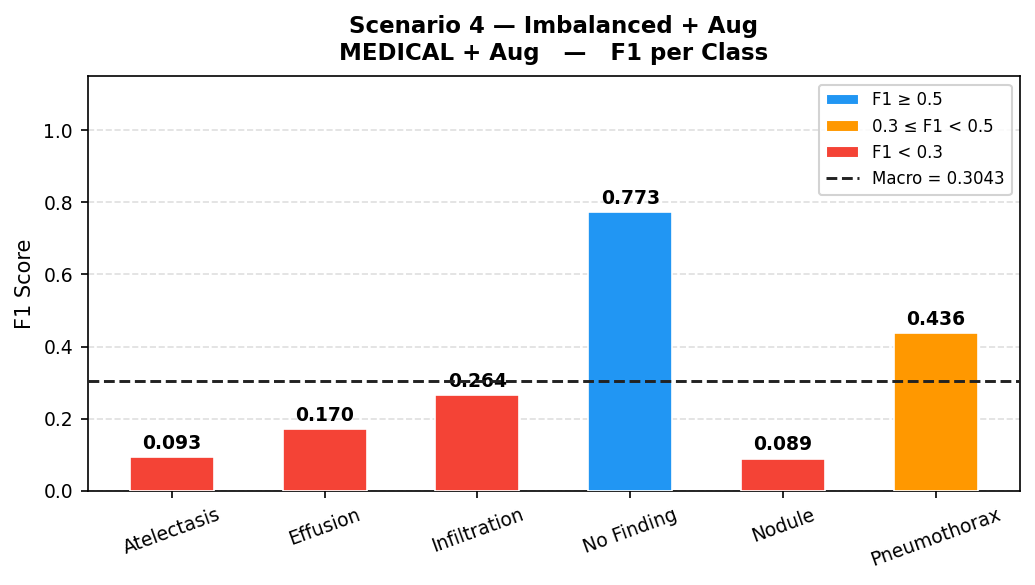

  Saved → f1cls_sc4_medical_imbalanced_aug.png

Done — semua F1-per-class tersimpan di: /content/drive/MyDrive/FP_Admin_KCV/fp/checkpoints


In [ ]:
# ============================================================
# CELL 12B — F1 Score per Class: 1 PNG per (Scenario × Model)
# ============================================================

def plot_f1_per_class(scenario_num, fe_tag, split_tag, use_aug):
    preds, labels = get_preds_from_ckpt(
        scenario_num, fe_tag, split_tag, use_aug
    )
    if preds is None:
        return

    f1_per = f1_score(labels, preds, average=None,    zero_division=0)
    f1_mac = f1_score(labels, preds, average='macro', zero_division=0)

    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

    # Warna bar berdasarkan nilai F1
    colors = [
        '#2196F3' if v >= 0.5 else
        '#FF9800' if v >= 0.3 else
        '#F44336'
        for v in f1_per
    ]

    bars = ax.bar(
        CLASS_NAMES, f1_per,
        color     = colors,
        edgecolor = 'white',
        linewidth = 0.8,
        width     = 0.55,
        zorder    = 3,
    )

    # Nilai di atas tiap bar
    for bar, val in zip(bars, f1_per):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.012,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
        )

    # Garis F1 macro
    ax.axhline(
        f1_mac, color='#222222', linewidth=1.4,
        linestyle='--', zorder=4,
        label=f'F1 Macro = {f1_mac:.4f}',
    )

    aug_str = ' + Aug' if use_aug else ''
    ax.set_title(
        f'{SCENARIO_LABELS_CM[scenario_num]}\n'
        f'{fe_tag.upper()}{aug_str}   —   F1 per Class',
        fontsize=11, fontweight='bold', pad=8,
    )
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', labelsize=9, rotation=20)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    # Legend: warna + garis macro
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor='#2196F3', edgecolor='white', label='F1 ≥ 0.5'),
        Patch(facecolor='#FF9800', edgecolor='white', label='0.3 ≤ F1 < 0.5'),
        Patch(facecolor='#F44336', edgecolor='white', label='F1 < 0.3'),
        plt.Line2D([0], [0], color='#222222', lw=1.4,
                   linestyle='--', label=f'Macro = {f1_mac:.4f}'),
    ]
    ax.legend(handles=legend_handles, fontsize=8,
              loc='upper right', framealpha=0.85)

    plt.tight_layout()

    aug_file = '_aug' if use_aug else ''
    out_path = CKPT_DIR / f'f1cls_sc{scenario_num}_{fe_tag}_{split_tag}{aug_file}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'  Saved → {out_path.name}')


# ── Jalankan ──────────────────────────────────────────────────

print('=== CELL 12B — F1 Score per Class ===\n')
for sc_num, fe, split, aug in EXPERIMENT_GRID:
    print(f'  Sc{sc_num} | {fe} | {split} | aug={aug}')
    plot_f1_per_class(sc_num, fe, split, aug)

print('\nDone — semua F1-per-class tersimpan di:', CKPT_DIR)

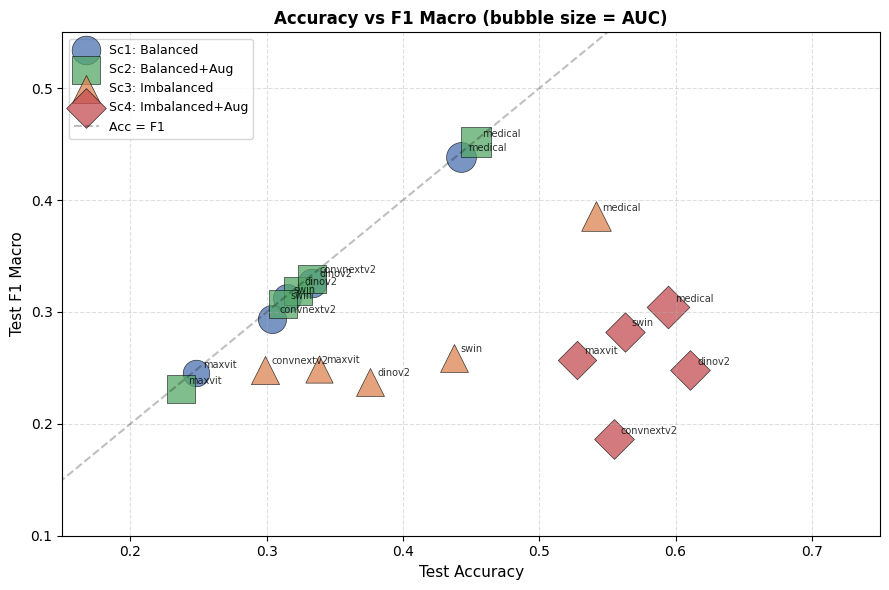

Scatter plot saved.


In [ ]:
# ============================================================
# CELL 15 — Scatter: Accuracy vs F1 (colour = scenario)
#            + size = AUC
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

sc_palette = {1: '#4C72B0', 2: '#55A868', 3: '#DD8452', 4: '#C44E52'}
sc_markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}

for _, row in summary_df.iterrows():
    sc  = row['Scenario']
    ax.scatter(
        row['Test Acc'], row['Test F1 (macro)'],
        s=row['Test AUC (OvR)'] * 600,
        color=sc_palette[sc],
        marker=sc_markers[sc],
        alpha=0.75,
        edgecolors='k', linewidths=0.5,
        label=SCENARIO_LABELS[sc]
    )
    ax.annotate(
        row['Model'],
        (row['Test Acc'], row['Test F1 (macro)']),
        textcoords='offset points', xytext=(5, 4),
        fontsize=7, alpha=0.8
    )

# Diagonal reference (perfect Acc = F1 → balanced classes)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.25, label='Acc = F1')

# De-dup legend
handles, labels = ax.get_legend_handles_labels()
seen, unique_h, unique_l = set(), [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l); unique_h.append(h); unique_l.append(l)
ax.legend(unique_h, unique_l, fontsize=9, loc='upper left')

ax.set_xlabel('Test Accuracy', fontsize=11)
ax.set_ylabel('Test F1 Macro', fontsize=11)
ax.set_title('Accuracy vs F1 Macro (bubble size = AUC)', fontsize=12, fontweight='bold')
ax.set_xlim(0.15, 0.75); ax.set_ylim(0.1, 0.55)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(CKPT_DIR / 'scatter_acc_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plot saved.')


In [ ]:
# ============================================================
# CELL SAVE — Export Best Model Weights (lengkap)
# ============================================================
# Menyimpan 3 format per experiment:
#   1. .pt   — state_dict saja (ringan, untuk resume training)
#   2. .pkl  — full bundle: weights + config + metrics + label map
#   3. best_overall.pt — 1 model terbaik dari semua experiment
#                        berdasarkan Test F1 Macro tertinggi
# ============================================================

import pickle
import json
import shutil
from datetime import datetime

EXPORT_DIR = CKPT_DIR / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Label map sesuai encoding di notebook
LABEL_MAP = {
    0: 'Atelectasis',
    1: 'Effusion',
    2: 'Infiltration',
    3: 'No Finding',
    4: 'Nodule',
    5: 'Pneumothorax',
}

EXPERIMENT_GRID = [
    (1, 'dinov2',     'balanced',   False),
    (1, 'swin',       'balanced',   False),
    (1, 'maxvit',     'balanced',   False),
    (1, 'convnextv2', 'balanced',   False),
    (1, 'medical',    'balanced',   False),
    (2, 'dinov2',     'balanced',   True),
    (2, 'swin',       'balanced',   True),
    (2, 'maxvit',     'balanced',   True),
    (2, 'convnextv2', 'balanced',   True),
    (2, 'medical',    'balanced',   True),
    (3, 'dinov2',     'imbalanced', False),
    (3, 'swin',       'imbalanced', False),
    (3, 'maxvit',     'imbalanced', False),
    (3, 'convnextv2', 'imbalanced', False),
    (3, 'medical',    'imbalanced', False),
    (4, 'dinov2',     'imbalanced', True),
    (4, 'swin',       'imbalanced', True),
    (4, 'maxvit',     'imbalanced', True),
    (4, 'convnextv2', 'imbalanced', True),
    (4, 'medical',    'imbalanced', True),
]

# Feat dim masing-masing backbone (dari output training)
FEAT_DIM_MAP = {
    'dinov2':     768,
    'swin':       1024,
    'maxvit':     768,
    'convnextv2': 1024,
    'medical':    128,
}


# ── Helper: ambil metrik dari summary_df ──────────────────────

def get_metrics_from_summary(scenario_num, fe_tag, split_tag, use_aug):
    """Ambil Test Acc, F1, AUC dari summary_df yang sudah ada."""
    aug_label = '+aug' if use_aug else ''
    dataset   = f'{split_tag}{aug_label}'
    row = summary_df[
        (summary_df['Scenario'] == scenario_num) &
        (summary_df['Model']    == fe_tag) &
        (summary_df['Dataset']  == dataset)
    ]
    if len(row) == 0:
        return {}
    row = row.iloc[0]
    return {
        'test_acc':       float(row['Test Acc']),
        'test_f1_macro':  float(row['Test F1 (macro)']),
        'test_auc_ovr':   float(row['Test AUC (OvR)']),
        'best_epoch':     int(row['Best Epoch']),
    }


# ── Export loop ───────────────────────────────────────────────

export_log  = []   # log semua file yang berhasil disimpan
best_f1     = -1.0
best_bundle = None
best_name   = None

print(f'Export dir: {EXPORT_DIR}\n')
print(f'{"=" * 60}')

for sc_num, fe, split, aug in EXPERIMENT_GRID:
    aug_label = '+aug' if aug else ''
    exp_tag   = f'sc{sc_num}_{fe}_{split}{aug_label}'
    ckpt_src  = CKPT_DIR / f'{exp_tag}_best.pt'

    if not ckpt_src.exists():
        print(f'  [SKIP] {exp_tag} — checkpoint tidak ditemukan')
        continue

    feat_dim = FEAT_DIM_MAP.get(fe)
    metrics  = get_metrics_from_summary(sc_num, fe, split, aug)

    print(f'  Exporting: {exp_tag}')
    if metrics:
        print(f'    F1={metrics["test_f1_macro"]:.4f}  '
              f'Acc={metrics["test_acc"]:.4f}  '
              f'AUC={metrics["test_auc_ovr"]:.4f}')

    # ── Load state_dict ───────────────────────────────────────
    state_dict = torch.load(ckpt_src, map_location='cpu')

    # ── 1. Simpan .pt (state_dict saja) ──────────────────────
    pt_path = EXPORT_DIR / f'{exp_tag}_weights.pt'
    torch.save(state_dict, pt_path)

    # ── 2. Simpan .pkl (full bundle) ─────────────────────────
    bundle = {
        # Identitas experiment
        'exp_tag':      exp_tag,
        'scenario':     sc_num,
        'fe_backbone':  fe,
        'split':        split,
        'use_aug':      aug,
        'exported_at':  datetime.now().isoformat(timespec='seconds'),

        # Konfigurasi model — cukup untuk rebuild MLPClassifier
        'model_class':  'MLPClassifier',
        'model_config': {
            'feat_dim':    feat_dim,
            'num_classes': NUM_CLASSES,
            'mlp_hidden':  MLP_HIDDEN,
            'dropout':     DROPOUT,
        },

        # Hyperparameter training
        'train_config': {
            'epochs':       EPOCHS,
            'batch_size':   BATCH_SIZE,
            'lr':           LR,
            'weight_decay': WEIGHT_DECAY,
            'seed':         SEED,
            'val_ratio':    VAL_RATIO,
            'test_ratio':   TEST_RATIO,
        },

        # Metrik test set
        'metrics': metrics,

        # Label map
        'label_map':    LABEL_MAP,

        # Weights
        'state_dict':   state_dict,
    }

    pkl_path = EXPORT_DIR / f'{exp_tag}_bundle.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

    # ── Catat ke log ──────────────────────────────────────────
    export_log.append({
        'exp_tag':  exp_tag,
        'pt_file':  pt_path.name,
        'pkl_file': pkl_path.name,
        **metrics,
    })

    # ── Cek apakah ini model terbaik overall ──────────────────
    f1_val = metrics.get('test_f1_macro', -1.0)
    if f1_val > best_f1:
        best_f1     = f1_val
        best_bundle = bundle
        best_name   = exp_tag

    print(f'    ✓ {pt_path.name}')
    print(f'    ✓ {pkl_path.name}')

print(f'\n{"=" * 60}')


# ── Simpan best overall ───────────────────────────────────────

if best_bundle is not None:
    # .pt
    best_pt_path = EXPORT_DIR / 'best_overall_weights.pt'
    torch.save(best_bundle['state_dict'], best_pt_path)

    # .pkl
    best_pkl_path = EXPORT_DIR / 'best_overall_bundle.pkl'
    with open(best_pkl_path, 'wb') as f:
        pickle.dump(best_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f'\n★  Best Overall Model: {best_name}')
    print(f'   F1 Macro = {best_f1:.4f}')
    print(f'   Saved → {best_pt_path.name}')
    print(f'   Saved → {best_pkl_path.name}')


# ── Simpan export log ke JSON dan CSV ─────────────────────────

if export_log:
    log_df = pd.DataFrame(export_log)

    log_csv = EXPORT_DIR / 'export_log.csv'
    log_df.to_csv(log_csv, index=False)

    log_json = EXPORT_DIR / 'export_log.json'
    with open(log_json, 'w') as f:
        json.dump(export_log, f, indent=2)

    print(f'\n{"=" * 60}')
    print(f'Export log ({len(export_log)} models):')
    print(log_df[['exp_tag', 'test_f1_macro', 'test_acc',
                  'test_auc_ovr']].to_string(index=False))
    print(f'\nLog disimpan → {log_csv.name}')
    print(f'Log disimpan → {log_json.name}')


# ── Preview cara load kembali ─────────────────────────────────

print(f"""
{"=" * 60}
CARA LOAD KEMBALI:

# -- Opsi 1: dari .pt (state_dict saja) --
model = MLPClassifier(feat_dim=768)   # sesuaikan feat_dim
model.load_state_dict(torch.load('exports/sc1_dinov2_balanced_weights.pt'))
model.eval()

# -- Opsi 2: dari .pkl (bundle lengkap) --
import pickle
with open('exports/sc1_dinov2_balanced_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

cfg   = bundle['model_config']
model = MLPClassifier(feat_dim=cfg['feat_dim'])
model.load_state_dict(bundle['state_dict'])
model.eval()

print(bundle['metrics'])      # lihat metrik
print(bundle['label_map'])    # lihat label kelas
{"=" * 60}
""")

Export dir: /content/drive/MyDrive/FP_Admin_KCV/fp/checkpoints/exports

  Exporting: sc1_dinov2_balanced
    F1=0.3261  Acc=0.3333  AUC=0.7100
    ✓ sc1_dinov2_balanced_weights.pt
    ✓ sc1_dinov2_balanced_bundle.pkl
  Exporting: sc1_swin_balanced
    F1=0.3122  Acc=0.3147  AUC=0.6763
    ✓ sc1_swin_balanced_weights.pt
    ✓ sc1_swin_balanced_bundle.pkl
  Exporting: sc1_maxvit_balanced
    F1=0.2454  Acc=0.2480  AUC=0.6080
    ✓ sc1_maxvit_balanced_weights.pt
    ✓ sc1_maxvit_balanced_bundle.pkl
  Exporting: sc1_convnextv2_balanced
    F1=0.2937  Acc=0.3040  AUC=0.6836
    ✓ sc1_convnextv2_balanced_weights.pt
    ✓ sc1_convnextv2_balanced_bundle.pkl
  Exporting: sc1_medical_balanced
    F1=0.4390  Acc=0.4427  AUC=0.7695
    ✓ sc1_medical_balanced_weights.pt
    ✓ sc1_medical_balanced_bundle.pkl
  Exporting: sc2_dinov2_balanced+aug
    F1=0.3191  Acc=0.3227  AUC=0.7097
    ✓ sc2_dinov2_balanced+aug_weights.pt
    ✓ sc2_dinov2_balanced+aug_bundle.pkl
  Exporting: sc2_swin_balanced+aug
  